# 🍊 내일의 제주 — 제주 특산물 가격 예측

## 팀 정보

| 항목 | 내용 |
|------|------|
| **팀명** | 내일의 제주 |
| **대회** | DACON 제주 특산물 가격 예측 AI 경진대회 |
| **DACON** | https://dacon.io/competitions/official/236176/overview/description |
| **GitHub** | https://github.com/chul3224/Tomorrow-Jeju |
| **진행 기간** | 2026-03-09 ~ 2026-03-18 |
| **발표일** | 2026-03-18 |

## 팀원 및 담당 파트

| 이름 | 역할 | 담당 파트 |
|------|------|----------|
| 박효준 (조장) | 데이터 탐색 및 시각화 | EDA |
| 김대원 | 피처 설계 및 앙상블 구조 | 피처 엔지니어링 |
| 신우철 | 모델 버전 관리 및 최종 통합 | 모델링 |

## 최종 모델 구성

| 항목 | 내용 |
|------|------|
| **모델** | LightGBM + XGBoost + CatBoost (VotingRegressor) + DNN 앙상블 |
| **그룹 전략** | TG / RD+CR / BC+CB — 3그룹 분리 학습 |
| **핵심 피처** | 달력 9개 + 명절 거리(dist_seollal, dist_chuseok) + 범주형 3개 |
| **타겟 변환** | TG → sqrt 변환 / 나머지 → log1p 변환 |
| **검증 방식** | 시즌 Hold-Out (2022-03) + 5-Fold 재학습 |
| **학습 기간** | 2019-01-01 ~ 2023-03-03 (59,397행) |
| **예측 기간** | 2023-03-04 ~ 2023-03-31 |

## 검증 결과 및 최종 점수

| 구분 | MAE |
|------|-----|
| Hold-Out 전체 MAE (2022-03) | **493.17** 원/kg |
| 예상 Public Score | **≈ 621** 원 |
| 팀 최고 Public Score (v1.0.1) | **658.6** 원 |

## v1.0 → v1.1 변경 사항

| 항목 | 내용 |
|------|------|
| Boxplot 이상치 시각화 | 이상치 처리 근거 시각화 추가 |
| 타겟 변환 전후 비교 | sqrt 변환 효과 히스토그램 추가 |
| 품목별 시계열 시각화 | 그룹 분리 근거 시각화 추가 |
| 일요일 0원 비율 히트맵 | 후처리 근거 시각화 추가 |
| 섹션별 마크다운 설명 | 각 처리 단계 이유 설명 보강 |

> 출력 파일: `results/submission_v13.1.csv`

---
## 1. 환경 설정 및 데이터 로드

In [ ]:
import os
import pandas as pd
import numpy as np
import datetime
import holidays
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

try:
    from korean_font import set_korean_font
    set_korean_font()
except:
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import VotingRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

DATA_PATH = 'data/'
train = pd.read_csv(DATA_PATH + 'train.csv', encoding='utf-8-sig')
test  = pd.read_csv(DATA_PATH + 'test.csv',  encoding='utf-8-sig')
sub   = pd.read_csv(DATA_PATH + 'sample_submission.csv', encoding='utf-8-sig')

train['timestamp'] = pd.to_datetime(train['timestamp'])
test['timestamp']  = pd.to_datetime(test['timestamp'])

print(f'Train: {train.shape}, Test: {test.shape}')

한글 폰트 설정: NanumGothic (/usr/share/fonts/truetype/nanum/NanumGothic.ttf)
Train: (59397, 7), Test: (1092, 5)


---
## 📊 EDA 파트 (박효준)

제주 농산물 가격 데이터 탐색적 분석: 품목별 가격 분포, 요일/계절성 패턴, 공휴일/명절 영향, 기상 재해 구간 분석

In [9]:
# EDA 파트 - 변수 정의 (박효준)
PRICE_COL  = 'price(원/kg)'
SUPPLY_COL = 'supply(kg)'
train_df = train.copy()  # 박효준님 EDA 코드와 변수명 호환
train_df.rename(columns={'price(원/kg)': 'price', 'supply(kg)': 'supply'}, inplace=True)
train_df['month'] = train_df['timestamp'].dt.month
print('EDA 파트 준비 완료 | train:', train.shape)

EDA 파트 준비 완료 | train: (59397, 7)


In [10]:
print("--- Train Missing Values ---")
print(train.isnull().sum())
print("\n--- Test Missing Values ---")
print(test.isnull().sum())

--- Train Missing Values ---
ID             0
timestamp      0
item           0
corporation    0
location       0
supply(kg)     0
price(원/kg)    0
dtype: int64

--- Test Missing Values ---
ID             0
timestamp      0
item           0
corporation    0
location       0
dtype: int64


In [11]:

# ─── ID 컬럼 구조 분석 ───────────────────────────────────────────────
print('=== ID 컬럼 구조 분석 ===')
sample_ids = train['ID'].head(10).tolist()
for sid in sample_ids:
    parts = sid.split('_')
    print(f'  {sid}  →  품목={parts[0]}, 법인={parts[1]}, 지역={parts[2]}, 날짜={parts[3]}')

print()
print('=== ID 파싱 검증 ===')
id_parsed = train['ID'].str.split('_', expand=True)
id_parsed.columns = ['item_id', 'corp_id', 'loc_id', 'date_id']

match_item = (id_parsed['item_id'] == train['item']).all()
match_corp = (id_parsed['corp_id'] == train['corporation']).all()
match_loc  = (id_parsed['loc_id']  == train['location']).all()
print(f'  ID의 품목 부분 == item 컬럼: {match_item}')
print(f'  ID의 법인 부분 == corporation 컬럼: {match_corp}')
print(f'  ID의 지역 부분 == location 컬럼: {match_loc}')

id_date_as_ts = pd.to_datetime(id_parsed['date_id'], format='%Y%m%d')
ts_col = pd.to_datetime(train['timestamp'])
match_date = (id_date_as_ts.values == ts_col.values).all()
print(f'  ID의 날짜 부분 == timestamp 컬럼: {match_date}')

print()
print('=== item 코드 의미 ===')
item_map = {'TG': '감귤 (Tangerine)', 'BC': '브로콜리 (Broccoli)',
            'RD': '무 (Radish)', 'CR': '당근 (Carrot)', 'CB': '양배추 (Cabbage)'}
for code, name in item_map.items():
    cnt = (train['item'] == code).sum()
    pct = cnt / len(train) * 100
    print(f'  {code}: {name:25s} → {cnt:,}행 ({pct:.1f}%)')

print()
print('=== corporation 코드 (법인) ===')
corp_counts = train['corporation'].value_counts().sort_index()
for code, cnt in corp_counts.items():
    items = train[train['corporation'] == code]['item'].unique().tolist()
    print(f'  법인 {code}: {cnt:,}행 ({cnt/len(train)*100:.1f}%)  담당 품목: {items}')

print()
print('=== location 코드 (지역) ===')
loc_map = {'J': '제주시 (Jeju-si)', 'S': '서귀포시 (Seogwipo-si)'}
for code, name in loc_map.items():
    cnt = (train['location'] == code).sum()
    pct = cnt / len(train) * 100
    items = train[train['location'] == code]['item'].unique().tolist()
    print(f'  {code}: {name:28s} → {cnt:,}행 ({pct:.1f}%)  품목: {items}')


=== ID 컬럼 구조 분석 ===
  TG_A_J_20190101  →  품목=TG, 법인=A, 지역=J, 날짜=20190101
  TG_A_J_20190102  →  품목=TG, 법인=A, 지역=J, 날짜=20190102
  TG_A_J_20190103  →  품목=TG, 법인=A, 지역=J, 날짜=20190103
  TG_A_J_20190104  →  품목=TG, 법인=A, 지역=J, 날짜=20190104
  TG_A_J_20190105  →  품목=TG, 법인=A, 지역=J, 날짜=20190105
  TG_A_J_20190106  →  품목=TG, 법인=A, 지역=J, 날짜=20190106
  TG_A_J_20190107  →  품목=TG, 법인=A, 지역=J, 날짜=20190107
  TG_A_J_20190108  →  품목=TG, 법인=A, 지역=J, 날짜=20190108
  TG_A_J_20190109  →  품목=TG, 법인=A, 지역=J, 날짜=20190109
  TG_A_J_20190110  →  품목=TG, 법인=A, 지역=J, 날짜=20190110

=== ID 파싱 검증 ===
  ID의 품목 부분 == item 컬럼: True
  ID의 법인 부분 == corporation 컬럼: True
  ID의 지역 부분 == location 컬럼: True
  ID의 날짜 부분 == timestamp 컬럼: True

=== item 코드 의미 ===
  TG: 감귤 (Tangerine)            → 15,230행 (25.6%)
  BC: 브로콜리 (Broccoli)           → 13,707행 (23.1%)
  RD: 무 (Radish)                → 12,184행 (20.5%)
  CR: 당근 (Carrot)               → 10,661행 (17.9%)
  CB: 양배추 (Cabbage)             → 7,615행 (12.8%)

=== corporation 코드 (법인) ===
  

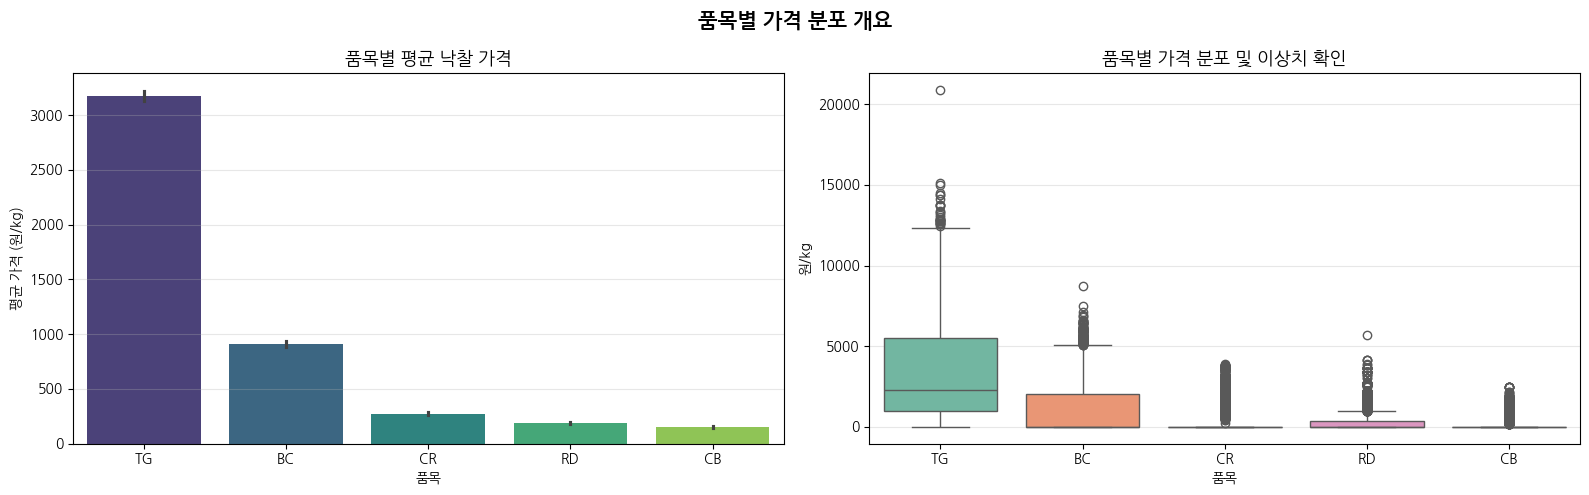


[품목별 가격 통계 — 이상치 임계값 설정 근거]
          평균     중앙값      최대값   99%ile
item                                  
BC     910.0     0.0   8750.0   5053.0
CB     152.0     0.0   2500.0   1462.0
CR     273.0     0.0   3882.0   2834.0
RD     187.0     0.0   5715.0   1613.0
TG    3177.0  2274.0  20909.0  10000.0


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (1) 품목별 평균 가격 — 막대 그래프
item_order = train.groupby('item')[PRICE_COL].mean().sort_values(ascending=False).index
sns.barplot(
    x='item', y=PRICE_COL, data=train,
    order=item_order, palette='viridis', ax=axes[0]
)
axes[0].set_title('품목별 평균 낙찰 가격', fontsize=13)
axes[0].set_xlabel('품목'); axes[0].set_ylabel('평균 가격 (원/kg)')
axes[0].grid(axis='y', alpha=0.3)

# (2) Boxplot — 분포 및 이상치
sns.boxplot(
    x='item', y=PRICE_COL, data=train,
    order=item_order, palette='Set2', ax=axes[1]
)
axes[1].set_title('품목별 가격 분포 및 이상치 확인', fontsize=13)
axes[1].set_xlabel('품목'); axes[1].set_ylabel('원/kg')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('품목별 가격 분포 개요', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/eda_01_price_dist.png', dpi=150, bbox_inches='tight') if False else None
plt.show()

# 이상치 임계값 근거 출력
print('\n[품목별 가격 통계 — 이상치 임계값 설정 근거]')
stats = train.groupby('item')[PRICE_COL].agg(['mean','median','max', lambda x: x.quantile(0.99)])
stats.columns = ['평균','중앙값','최대값','99%ile']
print(stats.round(0))

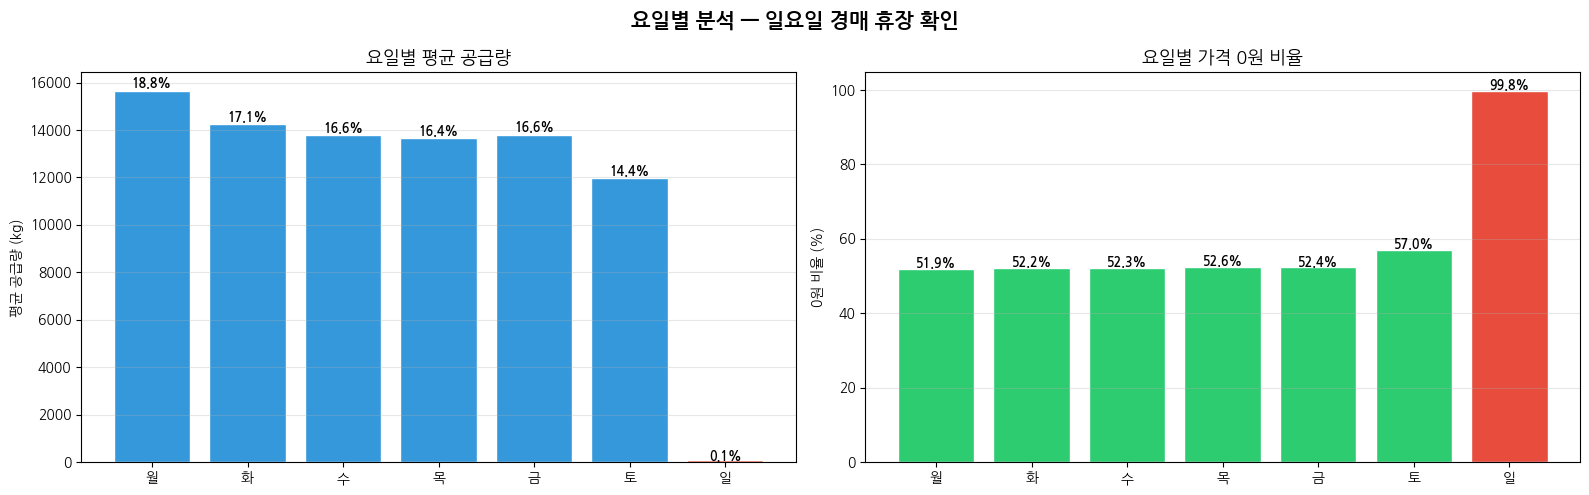


일요일 가격 0원 비율: 99.8%  →  후처리 시 일요일 예측값 0 처리 필요


In [13]:
train['day_of_week'] = train['timestamp'].dt.day_name()
DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
DOW_KR    = {'Monday':'월','Tuesday':'화','Wednesday':'수',
             'Thursday':'목','Friday':'금','Saturday':'토','Sunday':'일'}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (1) 요일별 평균 공급량
avg_supply = train.groupby('day_of_week')[SUPPLY_COL].mean().reindex(DOW_ORDER)
bars0 = axes[0].bar(
    [DOW_KR[d] for d in DOW_ORDER], avg_supply.values,
    color=['#e74c3c' if d == 'Sunday' else '#3498db' for d in DOW_ORDER],
    edgecolor='white'
)
for i, val in enumerate(avg_supply.values):
    pct = val / avg_supply.sum() * 100
    axes[0].text(i, val * 1.01, f'{pct:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('요일별 평균 공급량', fontsize=13)
axes[0].set_ylabel('평균 공급량 (kg)'); axes[0].grid(axis='y', alpha=0.3)

# (2) 요일별 0원 비율
zero_rate = train.groupby('day_of_week')[PRICE_COL].apply(
    lambda x: (x == 0).sum() / len(x) * 100
).reindex(DOW_ORDER)
bars1 = axes[1].bar(
    [DOW_KR[d] for d in DOW_ORDER], zero_rate.values,
    color=['#e74c3c' if d == 'Sunday' else '#2ecc71' for d in DOW_ORDER],
    edgecolor='white'
)
for i, val in enumerate(zero_rate.values):
    axes[1].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('요일별 가격 0원 비율', fontsize=13)
axes[1].set_ylabel('0원 비율 (%)'); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('요일별 분석 — 일요일 경매 휴장 확인', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

sun_zero = zero_rate['Sunday']
print(f'\n일요일 가격 0원 비율: {sun_zero:.1f}%  →  후처리 시 일요일 예측값 0 처리 필요')

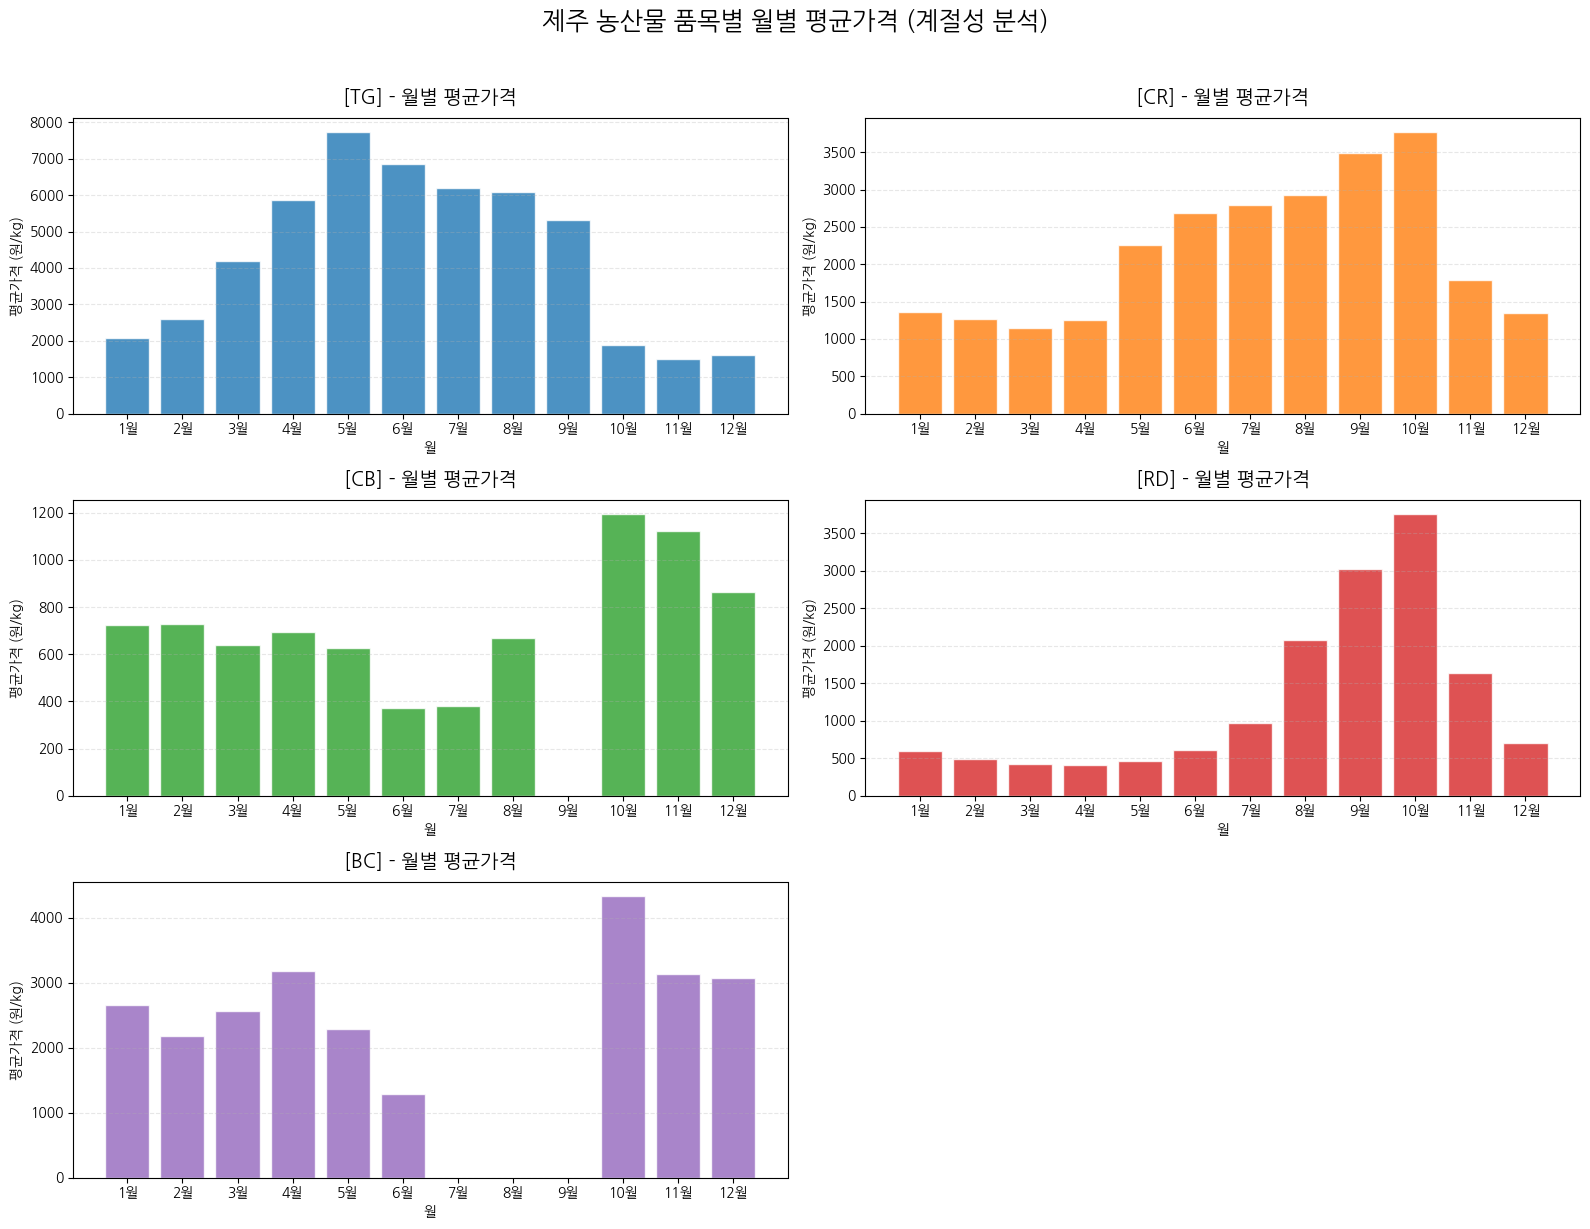

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 전처리 상태 확인 (컬럼명 및 month 생성)
if 'month' not in train_df.columns:
    train_df['month'] = train_df['timestamp'].dt.month

# 컬럼명 설정 (이전에 바꾼 이름에 맞춰 설정)
item_col = 'item'
target_col = 'price'  # 또는 'price(원/kg)'

# 2. 거래가 있는 데이터(0원 제외)만 필터링
df_plot = train_df[train_df[target_col] > 0].copy()

# 3. 시각화 설정
items = df_plot[item_col].unique()
n_items = len(items)
cols = 2
rows = (n_items + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
axes = axes.flatten()

# 4. 품목별 반복문 실행
for i, item in enumerate(items):
    # 품목별 데이터 추출 및 월별 평균 계산
    df_item = df_plot[df_plot[item_col] == item]
    monthly = df_item.groupby('month')[target_col].mean()
    
    # 막대 그래프 그리기 (품목마다 다른 색상 적용)
    axes[i].bar(monthly.index, monthly.values, color=f'C{i}', alpha=0.8, edgecolor='white')
    
    # 그래프 디테일 설정
    axes[i].set_title(f'[{item}] - 월별 평균가격', fontsize=14, pad=10)
    axes[i].set_xlabel('월')
    axes[i].set_ylabel('평균가격 (원/kg)')
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels([f'{m}월' for m in range(1, 13)], rotation=0)
    axes[i].grid(True, axis='y', alpha=0.3, linestyle='--')

# 사용하지 않는 빈 서브플롯은 숨기기
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# 전체 제목 및 레이아웃 조정
plt.suptitle('제주 농산물 품목별 월별 평균가격 (계절성 분석)', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

### 1. 감귤: 5월에 가격이 가장 비싼 이유
감귤은 겨울이 제철인 과일입니다. 5월에 최고가를 찍는 이유는 **'공급의 공백기'**와 '생산 방식의 변화' 때문입니다.

저장량 고갈: 노지 감귤(밖에서 키우는 귤)은 보통 1~2월이면 수확이 끝나고 저장 물량으로 버팁니다. 5월이 되면 이 저장 물량이 거의 바닥나서 희소성이 극대화됩니다.

하우스 감귤의 등장: 5월부터는 시설(하우스)에서 재배한 감귤이 나오기 시작합니다. 하우스 귤은 난방비 등 생산 원가가 훨씬 높기 때문에 시장 가격 자체가 매우 높게 형성됩니다.

대체재 부족: 5월은 딸기가 끝물이고 수박이 본격적으로 나오기 전이라 국산 과일 수요가 감귤로 몰리는 경향이 있습니다.
### 2. 당근: 5월~11월 가격이 낮은 이유
제주 당근은 전국 생산량의 상당 부분을 차지하는 **'겨울 당근'**이 주력입니다.

수입 당근과의 경쟁: 제주 당근 수확은 보통 12월~4월에 집중됩니다. 5월부터는 저장된 제주 당근이 시장에 풀리는데, 이때 중국산 수입 당근이나 육지(경남 등)의 봄 당근이 대량으로 쏟아져 나오면서 제주산의 가격 경쟁력이 떨어집니다.

품질 저하 가능성: 저장 기간이 길어질수록 수분이 빠지는 등 상품성이 낮아져 가격이 낮게 책정되기도 합니다.

### 3. 양배추: 5월 급락 후 10월까지 저렴한 이유
양배추의 가격 변동은 **'재배 지역의 이동'**을 보면 명확합니다.

육지산 대량 출하: 제주 양배추는 12월~4월이 주력입니다. 5월부터는 전남, 충남 등 육지에서 재배된 '봄 양배추'와 '여름 양배추'가 쏟아져 나옵니다.

지리적 불리함: 육지산이 시장(가락시장 등)에 가깝기 때문에 물류비가 비싼 제주산은 5~10월 사이에는 아예 경쟁력을 잃고 산지 폐기를 하거나 판매를 중단(데이터상 0원 혹은 낮은 가격)하게 됩니다.

11월 상승: 육지산 수확이 끝나는 11월부터 다시 '제주 겨울 양배추'의 시즌이 돌아오며 가격이 회복됩니다.

### 4. 무: 7월~11월 가격 하락 원인
무는 기온에 매우 민감한 작물입니다.

고랭지 무의 등장: 7월부터는 강원도 등에서 재배되는 고랭지 여름 무가 대량으로 공급됩니다.

공급 과잉: 여름부터 가을까지는 육지 곳곳에서 무가 생산되기 때문에 제주산 무(주로 겨울 무)가 비집고 들어갈 틈이 적습니다.

가을무 수확기: 10~11월은 전국적으로 김장철을 앞두고 가을무가 대량 출하되는 시기라 1년 중 공급량이 가장 많아 가격이 하락 압박을 받습니다.


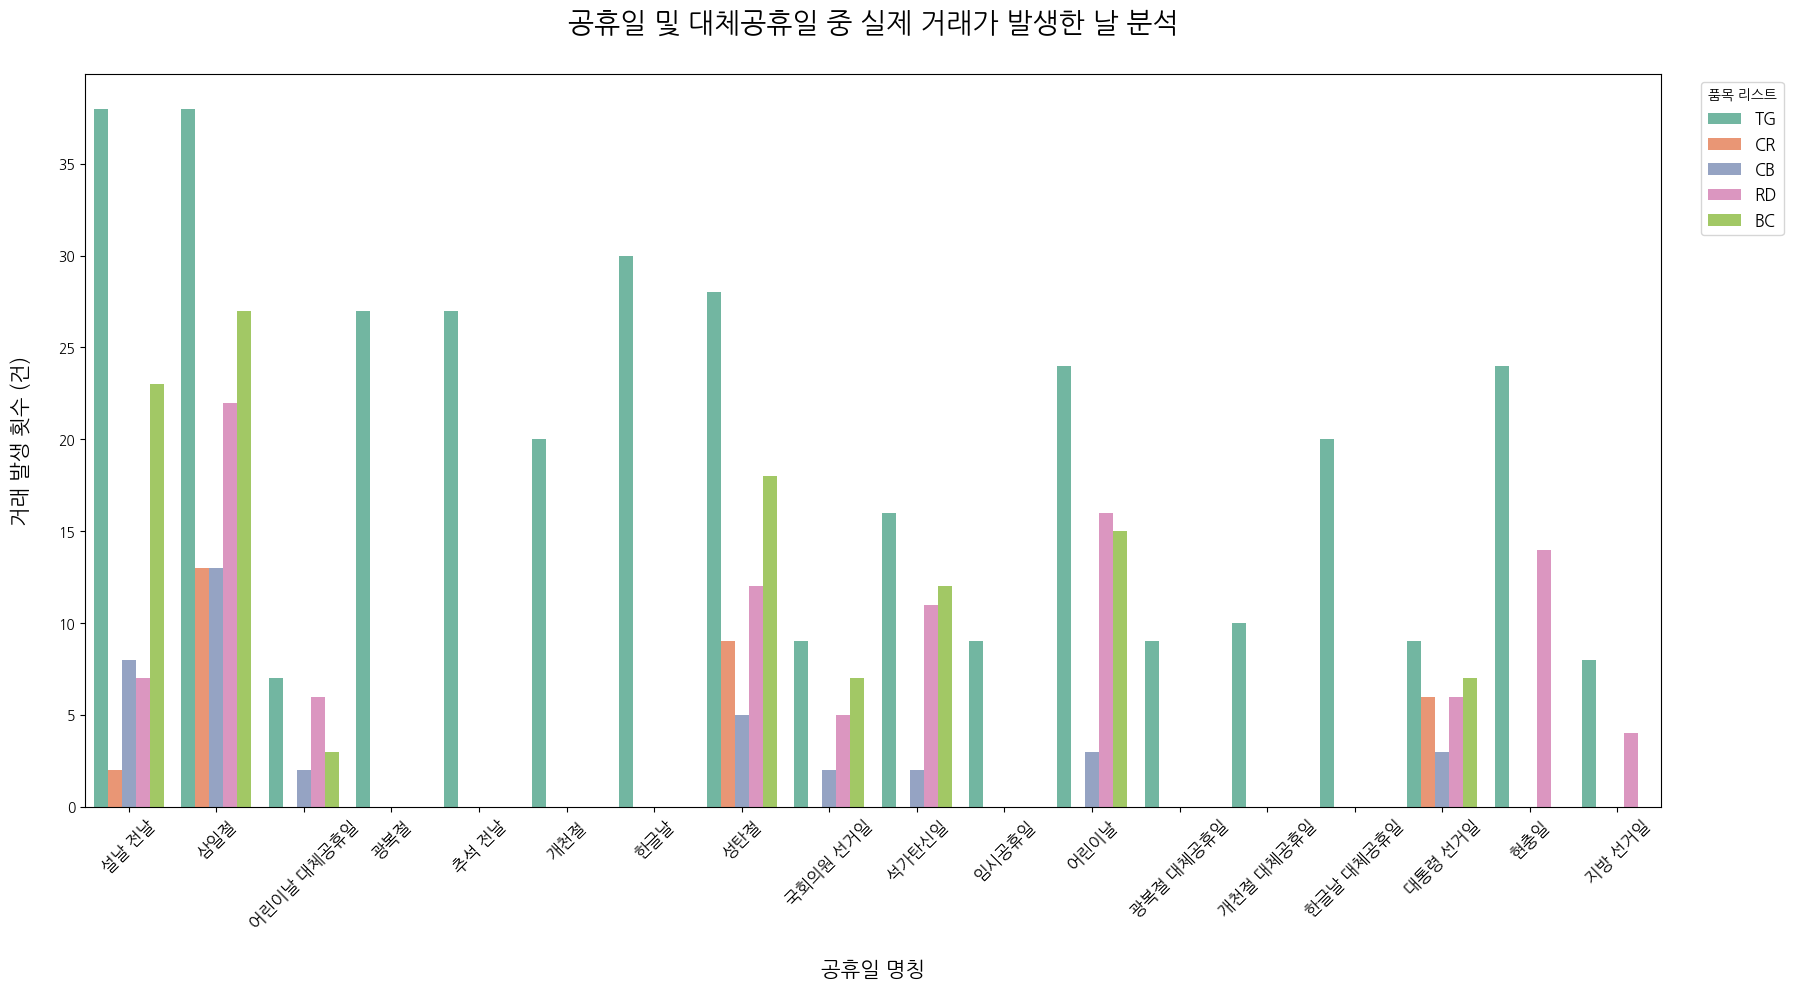

--- [공휴일 거래 상세 내역 (대체공휴일 포함)] ---


,날짜,공휴일명,품목,평균단가
0,2019-02-04,설날 전날,BC,2095.400000
1,2019-02-04,설날 전날,CB,261.500000
2,2019-02-04,설날 전날,RD,309.500000
3,2019-02-04,설날 전날,TG,2259.700000
4,2019-03-01,삼일절,BC,1997.571429
...,...,...,...,...
104,2023-03-01,삼일절,BC,3498.285714
105,2023-03-01,삼일절,CB,646.750000
106,2023-03-01,삼일절,CR,2031.750000
107,2023-03-01,삼일절,RD,585.800000


In [15]:
import pandas as pd
import holidays
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 공휴일 한글 매핑 딕셔너리 (이미지 속 영문 명칭 모두 포함)
holiday_ko = {
    # 신정
    "New Year's Day": "새해 첫날",
    "New Year's Year": "신정", 

    # 설날 (표준 및 변이형 통합)
    "Lunar New Year's Day": "설날",
    "The day preceding Lunar New Year's Day": "설날 전날",
    "The day after Lunar New Year's Day": "설날 다음날",
    "Korean New Year": "설날",
    "The day preceding Korean New Year's Day": "설날 전날",
    "The day after Korean New Year's Day": "설날 다음날",
    "The day preceding Korean New Year": "설날 전날", # 질문하신 명칭
    "The day after Korean New Year": "설날 다음날",
    "The second day of Korean New Year": "추석 셋째 날",
    
    # 삼일절 및 어린이날
    "Independence Movement Day": "삼일절",
    "Children's Day": "어린이날",
    
    # 부처님 오신 날 (표준 명칭 대응)
    "Buddha's Birthday": "석가탄신일",
    "Vesak": "석가탄신일",
    
    # 현충일, 제헌절, 광복절
    "Memorial Day": "현충일",
    "Constitution Day": "제헌절",
    "Liberation Day": "광복절",
    
    # 추석 (표준 및 변이형 통합)
    "Chuseok": "추석",
    "The day preceding Chuseok": "추석 전날",
    "The day after Chuseok": "추석 다음날",
    "The second day of Chuseok": "추석 둘째 날",
    
    # 개천절, 한글날, 성탄절
    "National Foundation Day": "개천절",
    "Hangul Day": "한글날",
    "Christmas Day": "성탄절",
    
    # 선거일 (추가)
    "National Assembly Election Day": "국회의원 선거일",
    "Presidential Election Day": "대통령 선거일",
    "Local Election Day": "지방 선거일",
    
    # 대체 공휴일 (패턴 대응)
    "Alternative holiday for Children's Day": "어린이날 대체공휴일",
    "Alternative holiday for Buddha's Birthday": "석가탄신일 대체공휴일",
    "Alternative holiday for Lunar New Year's Day": "설날 대체공휴일",
    "Alternative holiday for Korean New Year's Day": "설날 대체공휴일",
    "Alternative holiday for Chuseok": "추석 대체공휴일",
    "Alternative holiday for Independence Movement Day": "삼일절 대체공휴일",
    "Alternative holiday for Liberation Day": "광복절 대체공휴일",
    "Alternative holiday for National Foundation Day": "개천절 대체공휴일",
    "Alternative holiday for Hangul Day": "한글날 대체공휴일",
    "Alternative holiday for Constitution Day": "제헌절 대체공휴일",
    "Temporary Public Holiday": "임시공휴일", 
    "Alternative holiday for Korean New Year": "설날 대체공휴일",
}

# 2. 데이터 필터링 및 컬럼 설정
start_date = '2019-01-01'
end_date = '2023-03-03'
p_col = 'price' if 'price' in train_df.columns else 'price(원/kg)'

mask = (train_df['timestamp'] >= start_date) & (train_df['timestamp'] <= end_date)
target_df = train_df.loc[mask].copy()

# 3. 공휴일 정보 생성 및 한글화 적용
kr_holidays = holidays.KR()
target_df['is_holiday'] = target_df['timestamp'].apply(lambda x: 1 if x in kr_holidays else 0)
target_df['holiday_en'] = target_df['timestamp'].apply(lambda x: kr_holidays.get(x))
target_df['공휴일_명칭'] = target_df['holiday_en'].map(holiday_ko).fillna(target_df['holiday_en'])

# 4. 공휴일 중 실제 거래 발생 데이터 추출
sold_on_holiday = target_df[(target_df['is_holiday'] == 1) & (target_df[p_col] > 0)].copy()

# 5. 시각화 (간격 및 한글화 최적화)
if not sold_on_holiday.empty:
    plt.figure(figsize=(18, 10))
    
    # 막대 그래프 생성
    sns.countplot(data=sold_on_holiday, x='공휴일_명칭', hue='item', palette='Set2')
    
    # 텍스트 간격(pad) 및 한글화 설정
    plt.title('공휴일 및 대체공휴일 중 실제 거래가 발생한 날 분석', fontsize=20, pad=30)
    plt.xlabel('공휴일 명칭', fontsize=15, labelpad=20)
    plt.ylabel('거래 발생 횟수 (건)', fontsize=15, labelpad=20)
    
    # X축 눈금 설정 (간격을 위해 45도 회전)
    plt.xticks(rotation=45, fontsize=12)
    
    # 범례 설정 (한글화 및 위치 조정)
    plt.legend(title='품목 리스트', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12)
    
    plt.tight_layout()
    plt.show()

    # 결과 요약 표 출력
    summary = sold_on_holiday.groupby(['timestamp', '공휴일_명칭', 'item'])[p_col].mean().reset_index()
    summary.columns = ['날짜', '공휴일명', '품목', '평균단가']
    print("--- [공휴일 거래 상세 내역 (대체공휴일 포함)] ---")
    display(summary)

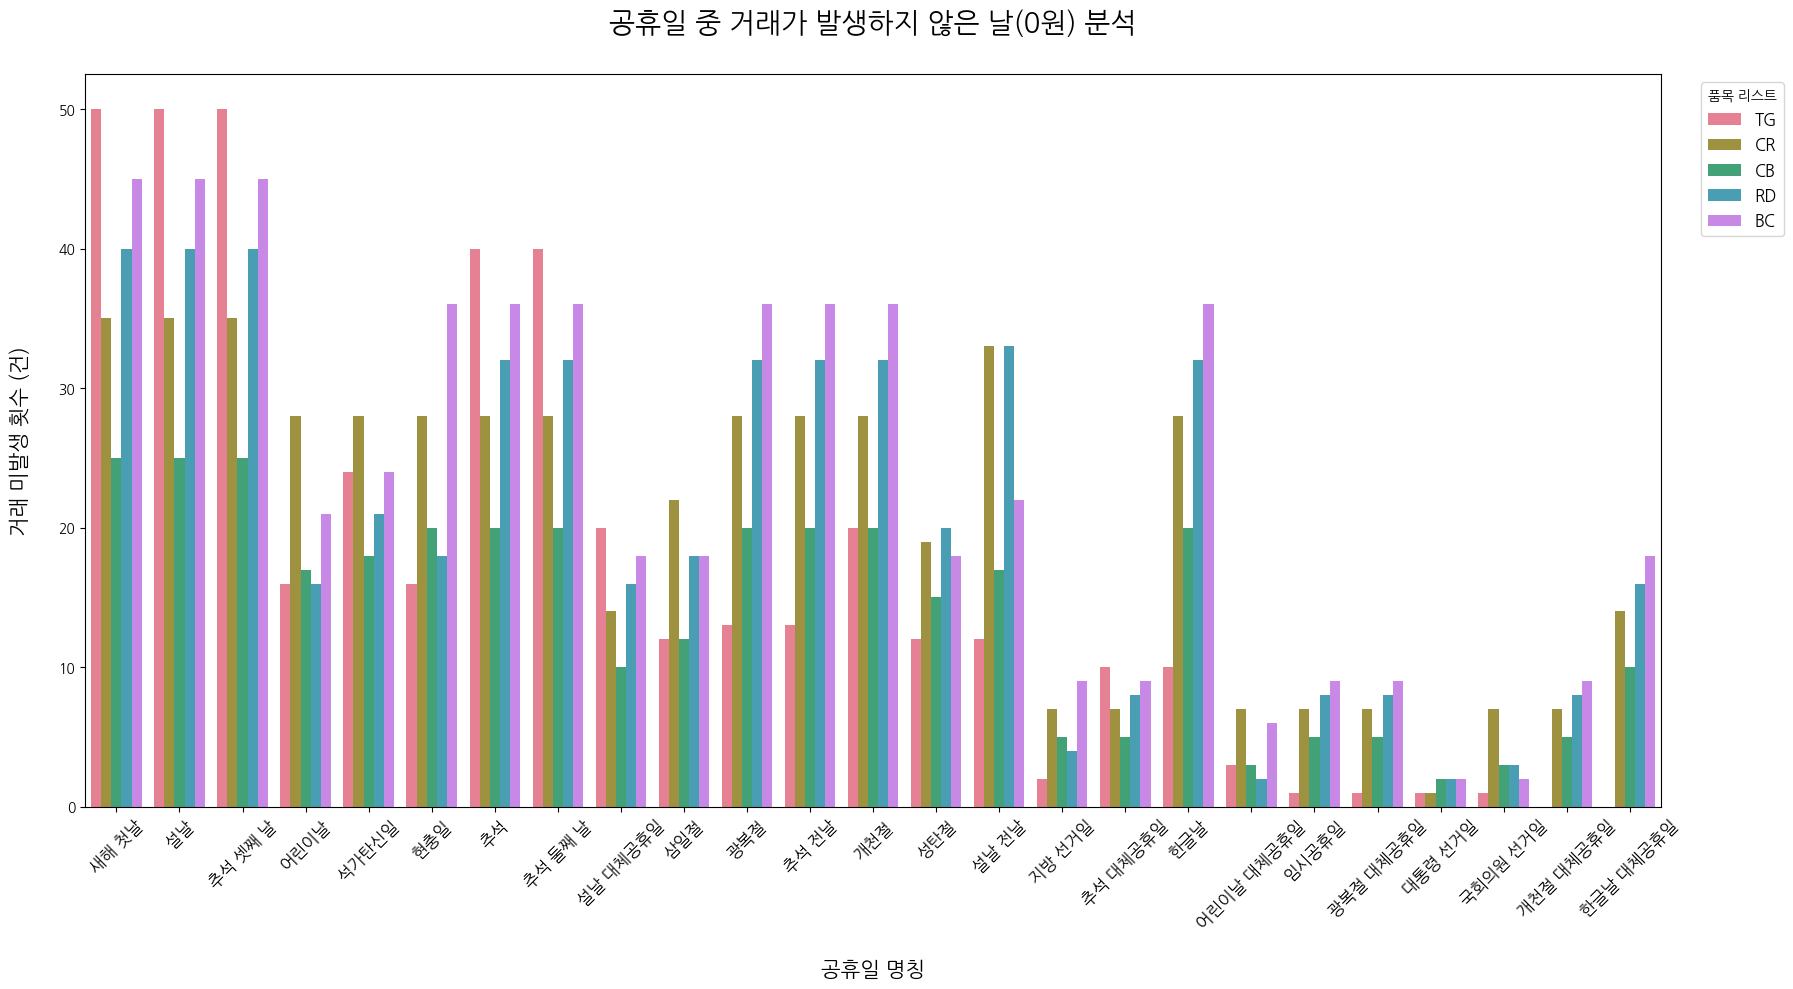

--- [거래 미발생 공휴일 상세 내역 (0원)] ---


,날짜,공휴일명,품목,데이터개수
0,2019-01-01,새해 첫날,BC,9
1,2019-01-01,새해 첫날,CB,5
2,2019-01-01,새해 첫날,CR,7
3,2019-01-01,새해 첫날,RD,8
4,2019-01-01,새해 첫날,TG,10
5,2019-02-04,설날 전날,BC,4
6,2019-02-04,설날 전날,CB,3
7,2019-02-04,설날 전날,CR,7
8,2019-02-04,설날 전날,RD,6
9,2019-02-05,설날,BC,9


In [16]:
# 4. "공휴일"이면서 "가격이 0원인(거래가 없는)" 데이터만 추출
# p_col 조건만 > 0 에서 == 0 으로 변경합니다.
no_trade_on_holiday = target_df[
    (target_df['is_holiday'] == 1) & 
    (target_df[p_col] == 0)
].copy()

# 5. 시각화 (거래 없는 공휴일 분석)
if not no_trade_on_holiday.empty:
    plt.figure(figsize=(18, 10))
    
    # 막대 그래프 생성 (거래가 없었던 횟수 카운트)
    sns.countplot(data=no_trade_on_holiday, x='공휴일_명칭', hue='item', palette='husl')
    
    plt.title('공휴일 중 거래가 발생하지 않은 날(0원) 분석', fontsize=20, pad=30)
    plt.xlabel('공휴일 명칭', fontsize=15, labelpad=20)
    plt.ylabel('거래 미발생 횟수 (건)', fontsize=15, labelpad=20)
    
    plt.xticks(rotation=45, fontsize=12)
    plt.legend(title='품목 리스트', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12)
    
    plt.tight_layout()
    plt.show()

    # 결과 요약 표 출력 (거래가 없었던 날짜 리스트)
    # 0원인 날의 평균을 내면 결과가 0이므로, 여기서는 날짜별 품목 리스트만 보여줍니다.
    summary_no_trade = no_trade_on_holiday.groupby(['timestamp', '공휴일_명칭', 'item']).size().reset_index()
    summary_no_trade.columns = ['날짜', '공휴일명', '품목', '데이터개수']
    print("--- [거래 미발생 공휴일 상세 내역 (0원)] ---")
    display(summary_no_trade.head(20)) # 너무 많을 수 있으니 상위 20개만 출력
else:
    print("분석 범위 내 모든 공휴일에 거래가 발생했습니다.")

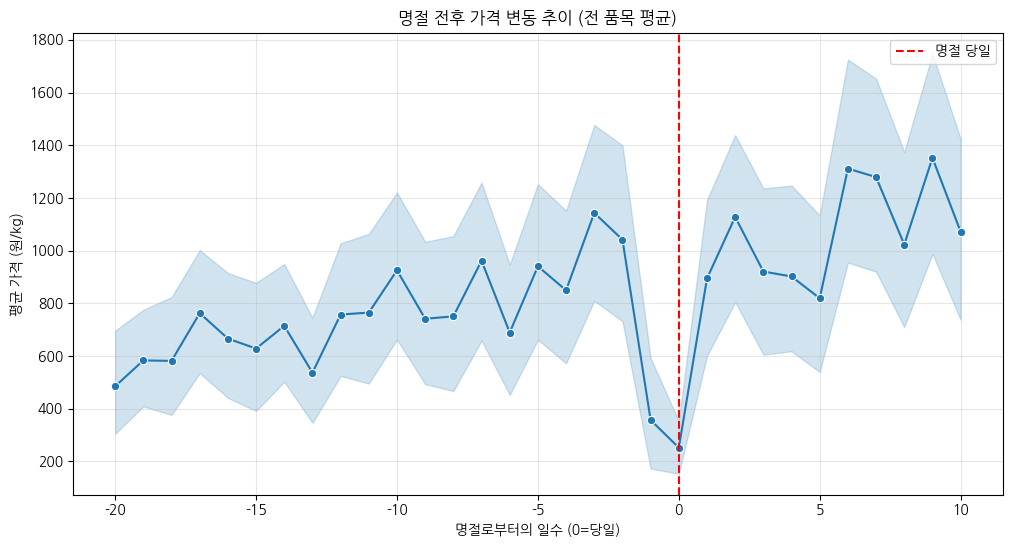

In [17]:
import holidays

kr_holidays = holidays.KR()

# 명절(설날, 추석) 날짜 추출 함수
def get_traditional_holidays(start_year, end_year):
    traditional_holidays = []
    for year in range(start_year, end_year + 1):
        for date, name in sorted(holidays.KR(years=year).items()):
            if 'Lunar New Year' in name or 'Chuseok' in name:
                traditional_holidays.append(date)
    return traditional_holidays

holiday_dates = get_traditional_holidays(2019, 2023)

def calculate_dist_to_holiday(date):
    curr_date = pd.to_datetime(date)
    diffs = [(pd.Timestamp(h) - curr_date).days for h in holiday_dates]
    min_diff = min(diffs, key=abs)
    return min_diff

train_holiday = train_df.copy()
train_holiday['dist_to_holiday'] = train_holiday['timestamp'].apply(calculate_dist_to_holiday)

plt.figure(figsize=(12, 6))
mask = (train_holiday['dist_to_holiday'] >= -20) & (train_holiday['dist_to_holiday'] <= 10)
sns.lineplot(x='dist_to_holiday', y='price', data=train_holiday[mask], marker='o')
plt.axvline(0, color='red', linestyle='--', label='명절 당일')
plt.title('명절 전후 가격 변동 추이 (전 품목 평균)')
plt.xlabel('명절로부터의 일수 (0=당일)')
plt.ylabel('평균 가격 (원/kg)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

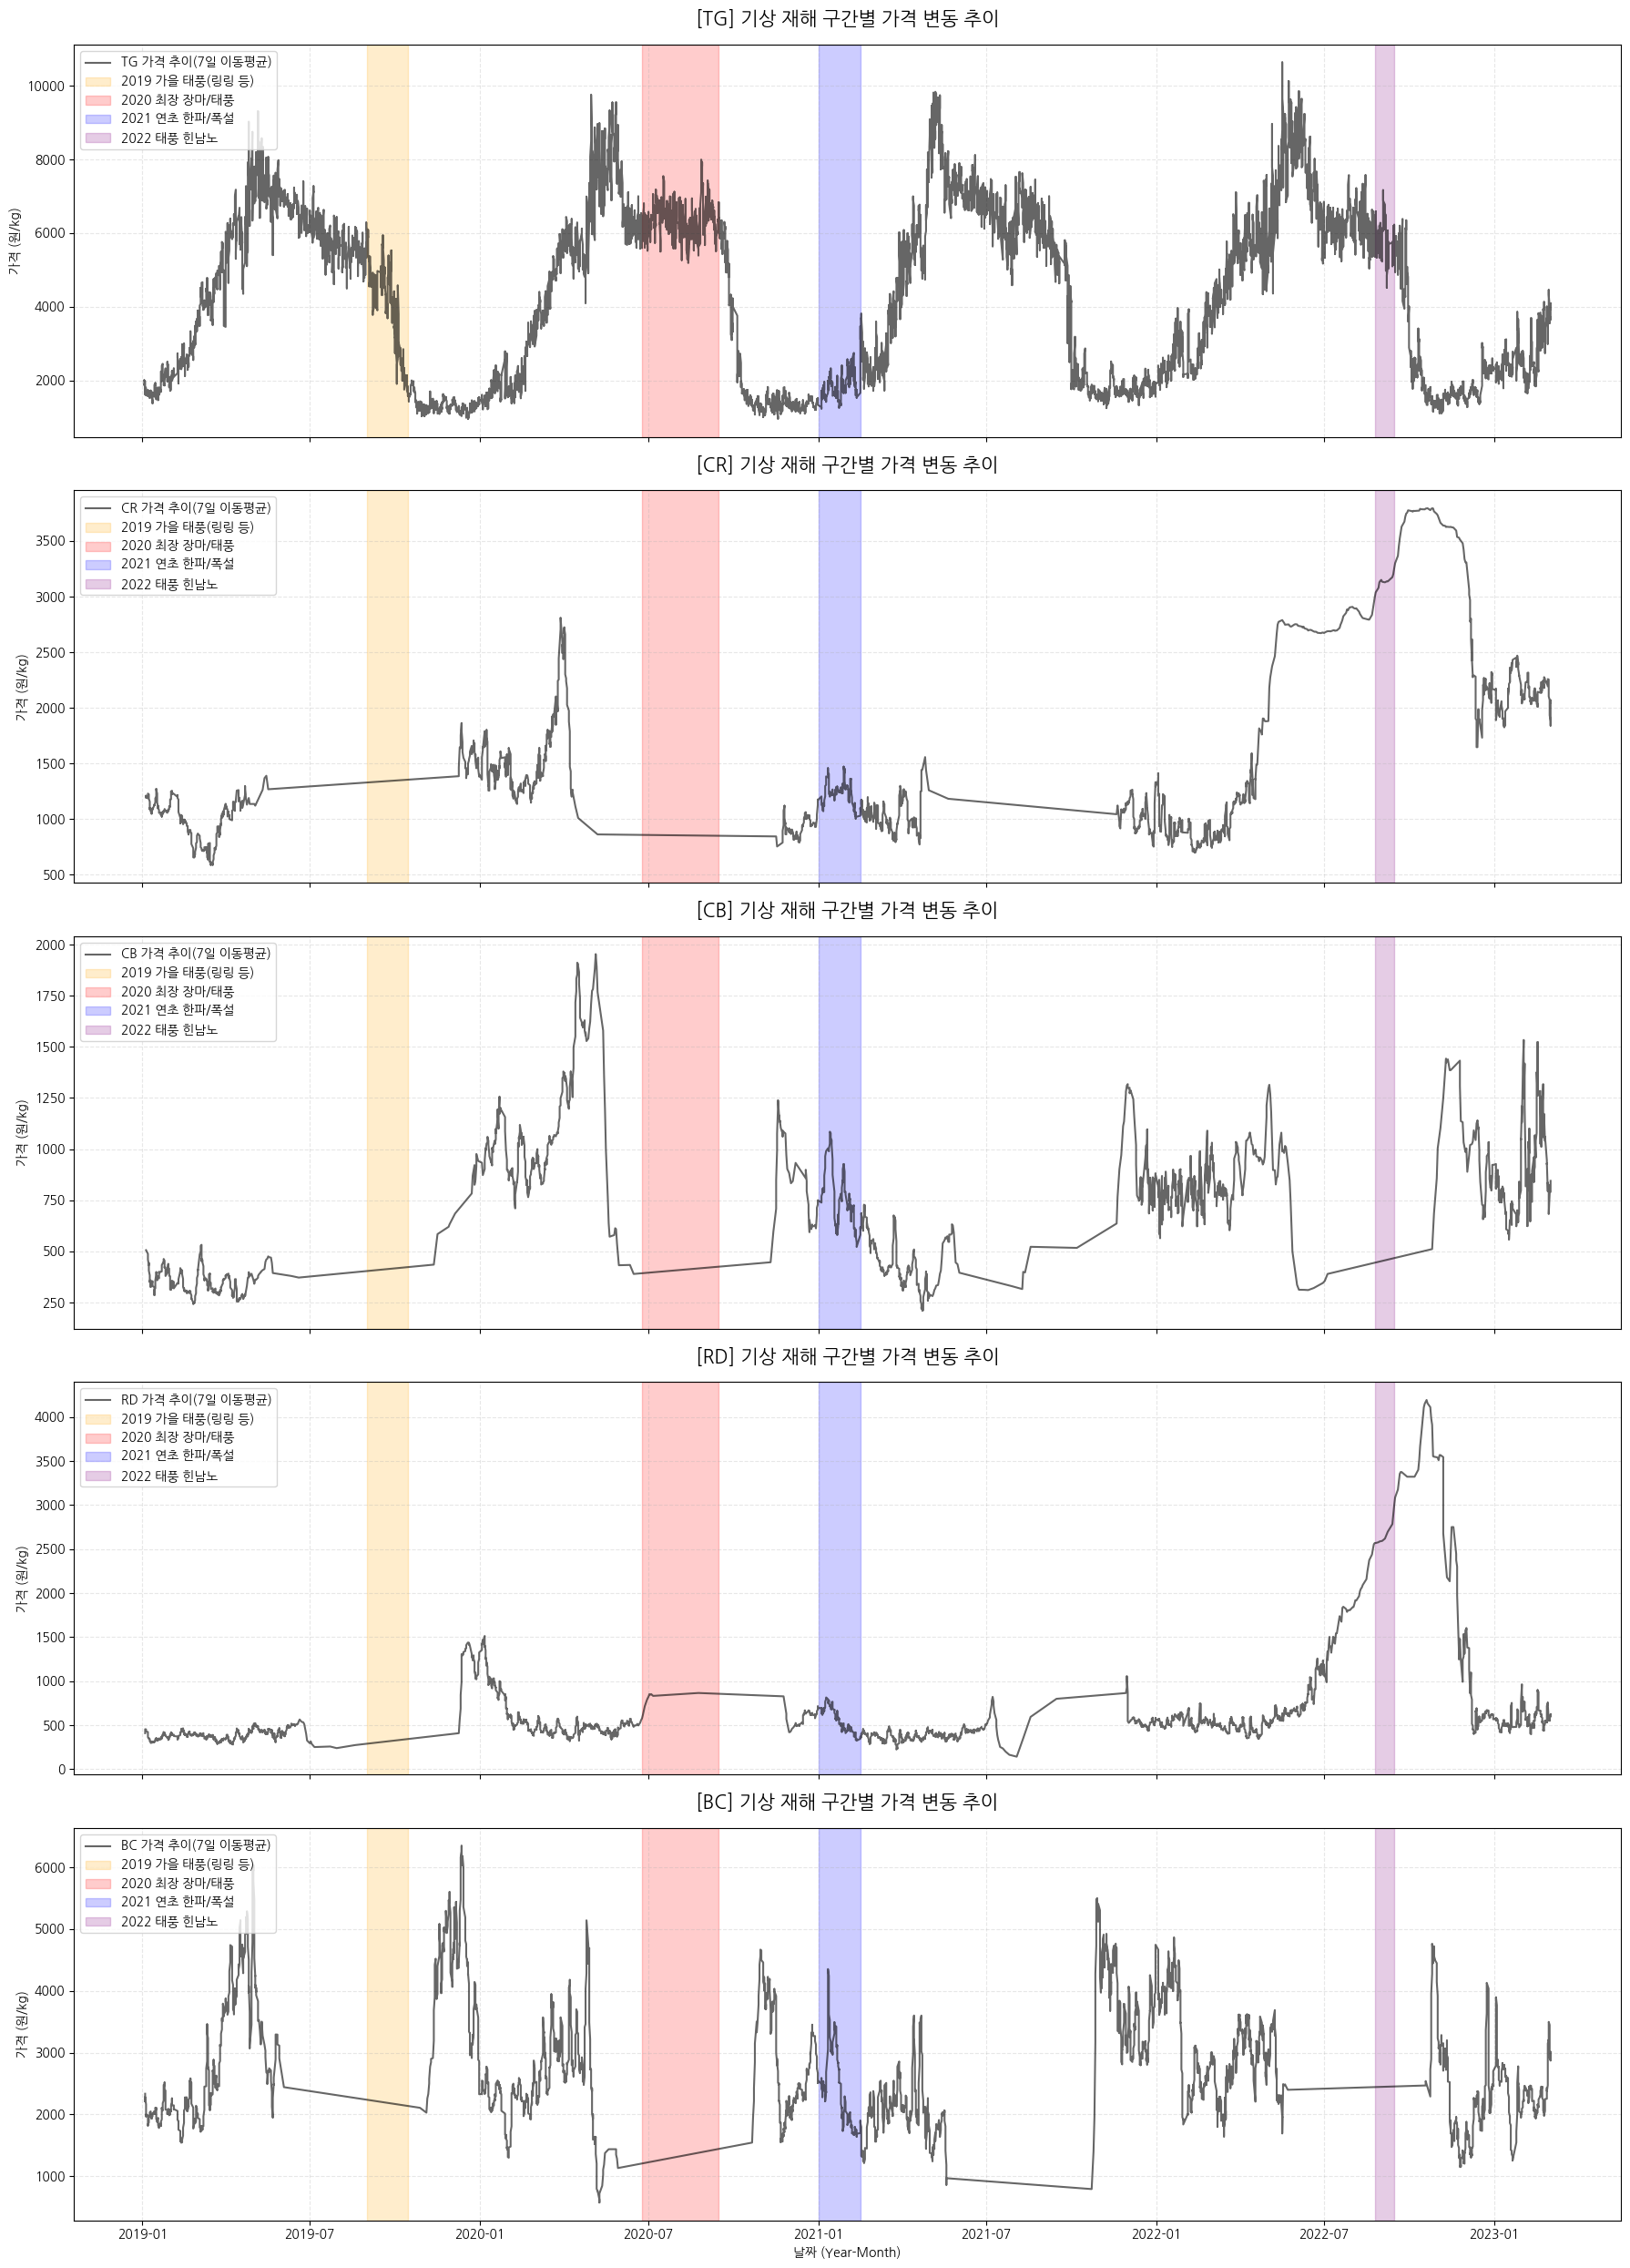

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 및 날짜 설정
target_col = 'price(원/kg)'

# 2. 분석에 활용할 기상 이변 기간 정의
weather_events = [
    {'name': '2019 가을 태풍(링링 등)', 'start': '2019-09-01', 'end': '2019-10-15', 'color': 'orange'},
    {'name': '2020 최장 장마/태풍', 'start': '2020-06-24', 'end': '2020-09-15', 'color': 'red'},
    {'name': '2021 연초 한파/폭설', 'start': '2021-01-01', 'end': '2021-02-15', 'color': 'blue'},
    {'name': '2022 태풍 힌남노', 'start': '2022-08-25', 'end': '2022-09-15', 'color': 'purple'}
]

# 3. 시각화 (품목별 가격 추이 + 기상 이변 구간 강조)
items = train['item'].unique()
fig, axes = plt.subplots(len(items), 1, figsize=(18, 5 * len(items)), sharex=True)

for i, item in enumerate(items):
    # 실제 거래 데이터(0원 제외) 추출 및 정렬
    item_df = train[(train['item'] == item) & (train[target_col] > 0)].copy()
    item_df = item_df.set_index('timestamp').sort_index()
    
    # 변동폭을 부드럽게 보기 위해 7일 이동평균 적용
    rolling_mean = item_df[target_col].rolling(window=7).mean()
    
    # 메인 가격 선 그래프
    axes[i].plot(rolling_mean.index, rolling_mean.values, label=f'{item} 가격 추이(7일 이동평균)', color='black', alpha=0.6)
    
    # 기상 이변 구간에 배경색(Shading) 입히기
    for event in weather_events:
        axes[i].axvspan(pd.to_datetime(event['start']), pd.to_datetime(event['end']), 
                        color=event['color'], alpha=0.2, label=event['name'])
    
    axes[i].set_title(f'[{item}] 기상 재해 구간별 가격 변동 추이', fontsize=15, pad=15)
    axes[i].set_ylabel('가격 (원/kg)')
    axes[i].grid(True, alpha=0.3, linestyle='--')
    
    # 중복 범례 제거 후 출력
    handles, labels = axes[i].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    axes[i].legend(by_label.values(), by_label.keys(), loc='upper left', fontsize=10)

plt.xlabel('날짜 (Year-Month)')
plt.tight_layout()
plt.show()

## 전처리 및 특성 엔지니어링

### 이상치 전처리
* 제주 농산물 가격 데이터에는 기상 이변이나 수급 불안정으로 인해 발생하는 비정상적인 고가가 존재합니다. <br>
* 이를 그대로 학습하면 모델이 과적합(Overfitting)될 수 있어, 품목별 임계값(Threshold)을 정해 유효한 거래 평균값으로 대체했습니다.

In [19]:
# 이상치 처리 - 각 품목의 평균으로 대체
outlier_thresholds = {'TG': 20000, 'RD': 5000, 'BC': 8000, 'CB': 2300}
for item, thr in outlier_thresholds.items():
    mask = (train['item'] == item) & (train['price(원/kg)'] > thr)
    if mask.any():
        mean_val = train[(train['item'] == item) & (train['price(원/kg)'] > 0)]['price(원/kg)'].mean()
        train.loc[mask, 'price(원/kg)'] = mean_val
        print(f'{item}: {mask.sum()}개 이상치 → 평균({mean_val:.0f})으로 대체')

print('이상치 처리 완료')

TG: 1개 이상치 → 평균(4145)으로 대체
RD: 1개 이상치 → 평균(564)으로 대체
BC: 1개 이상치 → 평균(2757)으로 대체
CB: 7개 이상치 → 평균(715)으로 대체
이상치 처리 완료


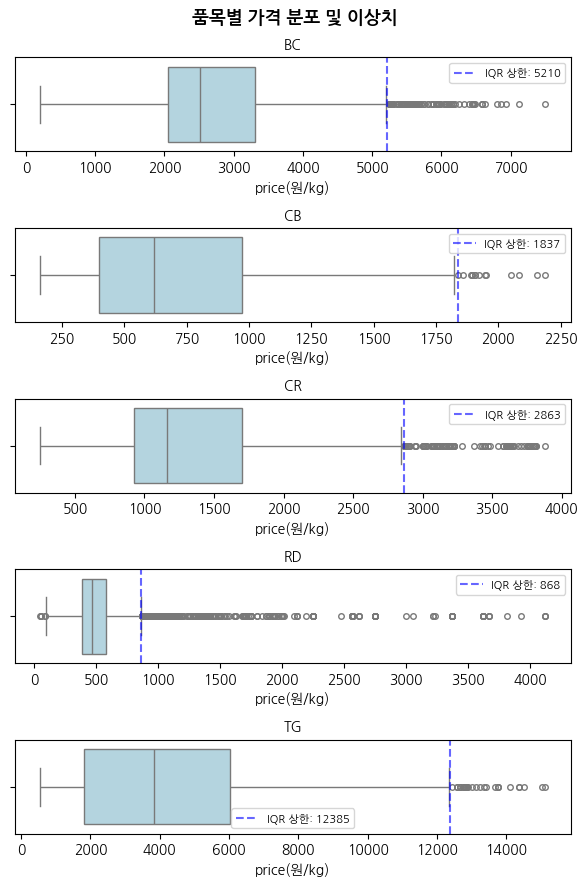

In [20]:
# Boxplot + IQR 이상치 확인
items = sorted(train['item'].unique())
fig, axes = plt.subplots(5, 1, figsize=(6, 9))
for i, item in enumerate(items):
    df_i = train[(train['item'] == item) & (train['price(원/kg)'] > 0)]
    Q1, Q3 = df_i['price(원/kg)'].quantile([0.25, 0.75])
    upper = Q3 + 1.5 * (Q3 - Q1)
    sns.boxplot(data=df_i, x='price(원/kg)', ax=axes[i], color='lightblue', fliersize=4)
    axes[i].axvline(upper, color='blue', linestyle='--', alpha=0.6, label=f'IQR 상한: {upper:.0f}')
    axes[i].set_title(f'{item}', fontsize=10)
    axes[i].legend(fontsize=8)
plt.suptitle('품목별 가격 분포 및 이상치', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 특성 엔지니어링


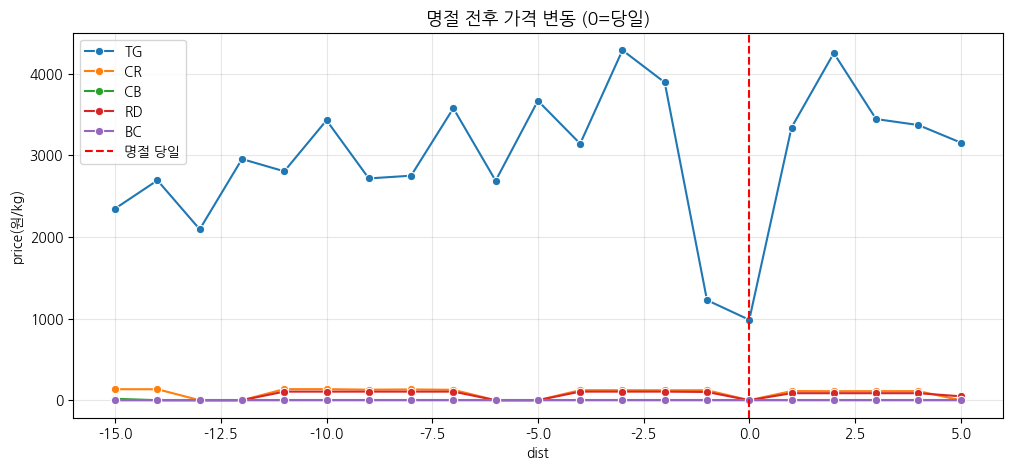

In [21]:
# 명절 전후 가격 변동
def get_trad_holidays(years):
    kr_h = holidays.KR(years=years)
    return sorted([d for d, n in kr_h.items()
                   if any(k in n for k in ['설날','추석','Lunar','Chuseok'])])

holiday_dates = get_trad_holidays(range(2019, 2024))

def calc_dist(date):
    diffs = [(pd.Timestamp(h).date() - date.date()).days for h in holiday_dates]
    return min(diffs, key=abs)

train_h = train.copy()
train_h['dist'] = train_h['timestamp'].apply(calc_dist)

mask = (train_h['dist'] >= -15) & (train_h['dist'] <= 5)
plt.figure(figsize=(12, 5))
sns.lineplot(x='dist', y='price(원/kg)', hue='item',
             data=train_h[mask], marker='o', errorbar=None)
plt.axvline(0, color='red', linestyle='--', label='명절 당일')
plt.title('명절 전후 가격 변동 (0=당일)', fontsize=13)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [22]:
# 명절 날짜 - 음력으로 정해지기에 직접 지정해줌
SEOLLAL = [pd.Timestamp(d) for d in ['2019-02-05','2020-01-25','2021-02-12','2022-02-01','2023-01-22']]
CHUSEOK = [pd.Timestamp(d) for d in ['2019-09-13','2020-10-01','2021-09-21','2022-09-10','2023-09-29']]

def preprocess(df):
    df = df.copy()
    df['year']     = df['timestamp'].dt.year
    df['month']    = df['timestamp'].dt.month
    df['day']      = df['timestamp'].dt.day
    df['dow']      = df['timestamp'].dt.dayofweek

    # week_num: 2019-01-01 기준 절대 주차
    df['week_num'] = (df['timestamp'] - pd.to_datetime('2019-01-01')).dt.days // 7

    # year_month: 누적 개월 수 LabelEncoding (v1.0.1 핵심)
    # → 트리·DNN 모두 시간 흐름을 인식
    df['year_month_str'] = df['timestamp'].map(lambda x: f'{x.year}-{x.month}')

    # 명절 거리 피처 (v5.0.0 + kim-dw 동일)
    df['dist_seollal'] = df['timestamp'].map(
        lambda d: min(min(abs((d - h).days) for h in SEOLLAL), 30)
    )
    df['dist_chuseok'] = df['timestamp'].map(
        lambda d: min(min(abs((d - h).days) for h in CHUSEOK), 30)
    )

    # holiday
    kr_h = holidays.KR()
    df['holiday'] = df['timestamp'].apply(lambda x: 1 if x in kr_h else 0)

    return df

train_p = preprocess(train)
test_p  = preprocess(test)

# year_month LabelEncoding — train+test 합쳐서 fit (인코딩 일관성)
le_ym = LabelEncoder()
le_ym.fit(pd.concat([train_p, test_p])['year_month_str'])
train_p['year_month'] = le_ym.transform(train_p['year_month_str'])
test_p['year_month']  = le_ym.transform(test_p['year_month_str'])

# TG 공휴일 보정: 공휴일이지만 실제 거래된 날은 holiday=0으로 수정
no_holiday = train_p[(train_p['holiday'] == 1) & (train_p['price(원/kg)'] > 0)]['timestamp'].unique()
train_p.loc[train_p['timestamp'].isin(no_holiday), 'holiday'] = 0
test_p.loc[test_p['timestamp'].isin(no_holiday), 'holiday'] = 0

print('전처리 완료')
print(f'피처 목록 확인: year_month={train_p["year_month"].nunique()}개 고유값')

전처리 완료
피처 목록 확인: year_month=51개 고유값


- **`year_month` (누적 개월)**: 단순 월(1~12) 정보만으로는 시간이 흐름에 따른 물가 상승이나 장기 추세를 반영하기 어렵습니다. 2019년 1월부터의 누적 개월수를 인코딩하여 모델이 시간의 흐름을 인식하게 했습니다.
- **명절 거리 피처 (`dist_seollal`, `dist_chuseok`)**: 제주 농산물은 명절 전후로 수요가 급증합니다. 명절 당일로부터의 거리(일수)를 피처로 추가하여 시즌 특성을 반영했습니다.
- **공휴일 보정**: 공휴일이지만 실제 거래가 발생한 날은 '영업일'로 간주하여 데이터를 정제했습니다.

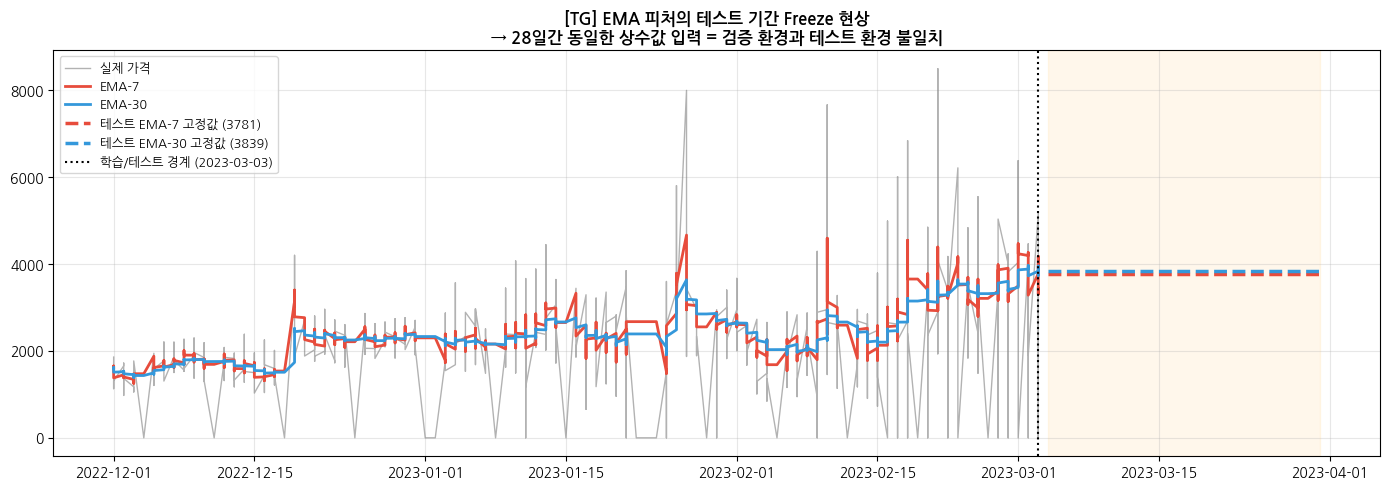

▶ EMA 제외 근거
  학습 기간: 매일 실제 가격으로 EMA 업데이트 → 추세 정보 유효
  테스트 기간(28일): EMA = 3781 (고정) → 모든 날 동일한 입력
  결과: v4.1.0 EMA 포함 → Public Score 1,170.5 (EMA 없는 v1.0.1 대비 +78% 악화)


In [23]:
# =====================================================
# 📌 [발표 대본 섹션 2] EMA 피처 실험 및 Freeze 시각화
# =====================================================
# EMA 피처 실험 및 freeze 문제 시각화
# ─────────────────────────────────────────────────────────────────
# EMA(Exponential Moving Average): 최근값에 높은 가중치를 부여한 이동평균
# 학습 기간에는 매일 실제 가격으로 업데이트 → 추세 반영 가능
# 테스트 기간(2023-03-04~31)에는 실제 가격이 없어 마지막 학습값으로 28일간 고정(freeze)
# ─────────────────────────────────────────────────────────────────

item_viz = 'TG'
df_viz = train[train['item'] == item_viz].copy().sort_values('timestamp')

# EMA 계산 (학습 데이터 기준)
for span in [7, 30]:
    df_viz[f'ema_{span}'] = (
        df_viz['price(원/kg)']
        .replace(0, np.nan)
        .ewm(span=span, min_periods=1)
        .mean()
    )

# 시각화: 학습 마지막 3개월 + 테스트 기간의 EMA freeze 현상
cutoff = pd.Timestamp('2023-03-03')
test_start = pd.Timestamp('2023-03-04')
test_end   = pd.Timestamp('2023-03-31')

df_recent = df_viz[df_viz['timestamp'] >= '2022-12-01']
last_ema7  = df_viz[df_viz['timestamp'] == cutoff]['ema_7'].values[0]
last_ema30 = df_viz[df_viz['timestamp'] == cutoff]['ema_30'].values[0]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_recent['timestamp'], df_recent['price(원/kg)'],
        color='gray', lw=1, alpha=0.6, label='실제 가격')
ax.plot(df_recent['timestamp'], df_recent['ema_7'],
        color='#e74c3c', lw=2, label='EMA-7')
ax.plot(df_recent['timestamp'], df_recent['ema_30'],
        color='#3498db', lw=2, label='EMA-30')

# 테스트 기간 freeze 표시
test_range = pd.date_range(test_start, test_end, freq='D')
ax.hlines(last_ema7,  test_start, test_end,
          colors='#e74c3c', lw=2.5, linestyles='--', label=f'테스트 EMA-7 고정값 ({last_ema7:.0f})')
ax.hlines(last_ema30, test_start, test_end,
          colors='#3498db', lw=2.5, linestyles='--', label=f'테스트 EMA-30 고정값 ({last_ema30:.0f})')

ax.axvspan(test_start, test_end, alpha=0.08, color='orange')
ax.axvline(cutoff, color='black', lw=1.5, linestyle=':', label='학습/테스트 경계 (2023-03-03)')
ax.set_title(f'[{item_viz}] EMA 피처의 테스트 기간 Freeze 현상\n'
             f'→ 28일간 동일한 상수값 입력 = 검증 환경과 테스트 환경 불일치',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('▶ EMA 제외 근거')
print(f'  학습 기간: 매일 실제 가격으로 EMA 업데이트 → 추세 정보 유효')
print(f'  테스트 기간(28일): EMA = {last_ema7:.0f} (고정) → 모든 날 동일한 입력')
print(f'  결과: v4.1.0 EMA 포함 → Public Score 1,170.5 (EMA 없는 v1.0.1 대비 +78% 악화)')

---
### EMA(지수이동평균) 피처 — 실험과 제외 이유

> **EMA란?** 최근 날짜에 더 높은 가중치를 부여하는 이동평균으로, 가격의 단기 추세를 포착합니다.  
> 저희 팀은 EMA 피처를 실험했으나 **테스트 기간 freeze 문제**로 최종 모델에서 제외했습니다.

### 타겟 변환
* 가격 데이터의 왜도(Skewness)를 낮추기 위해 변환을 적용했습니다. 감귤(TG)은 `sqrt`(제곱근) 변환, 나머지 품목은 `log1p`(로그) 변환을 통해 정규성을 확보했습니다.

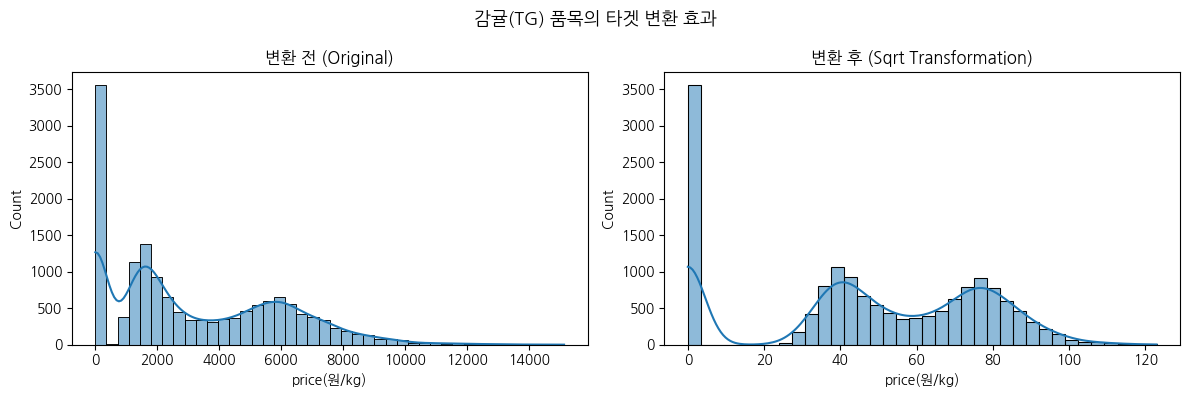

In [24]:
# 타겟 변환 전후 시각화 예시 (TG)
tg_data = train[train['item'] == 'TG']['price(원/kg)']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(tg_data, kde=True, ax=axes[0])
axes[0].set_title('변환 전 (Original)')
sns.histplot(np.sqrt(tg_data), kde=True, ax=axes[1])
axes[1].set_title('변환 후 (Sqrt Transformation)')
plt.suptitle('감귤(TG) 품목의 타겟 변환 효과', fontsize=13)
plt.tight_layout()
plt.show()

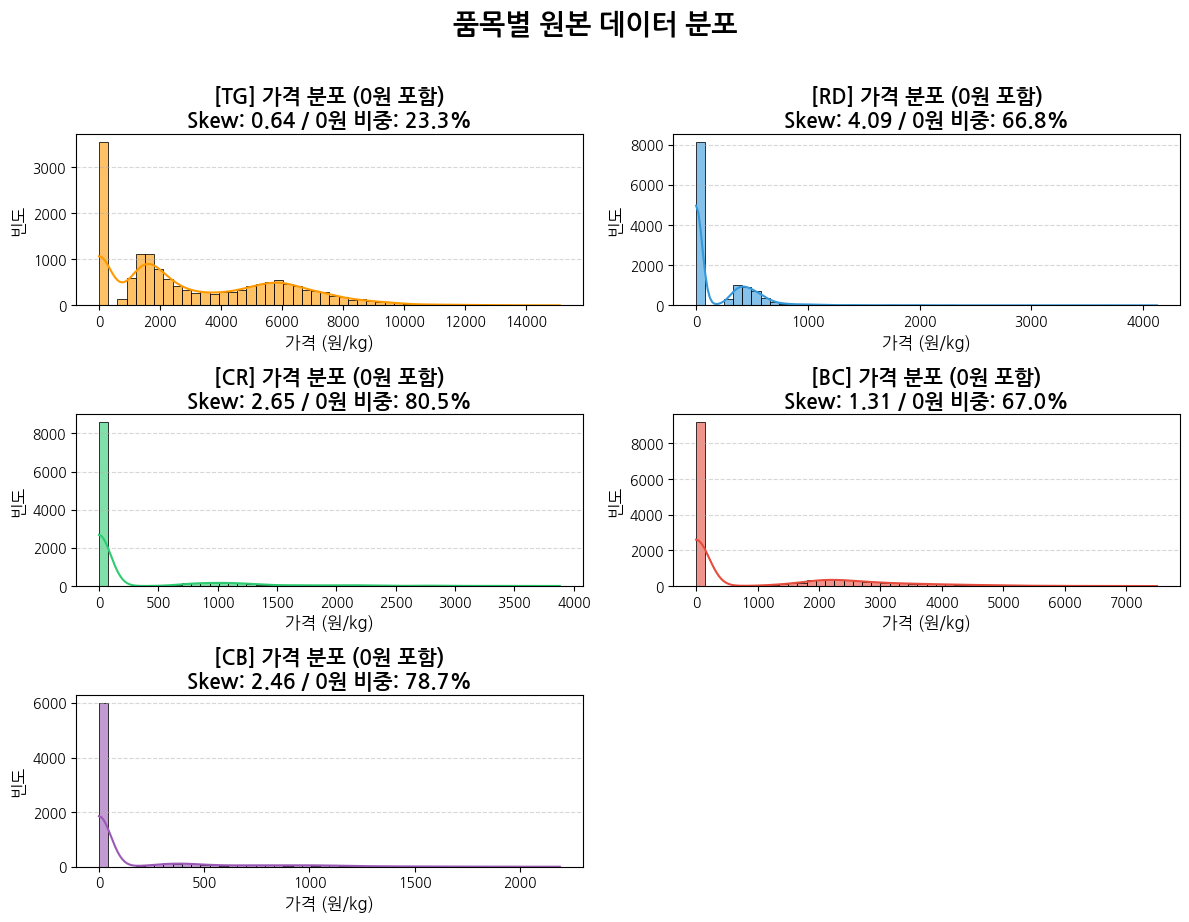

In [39]:
# 5개 주요 품목 및 색상 설정
items = ['TG', 'RD', 'CR', 'BC', 'CB']
colors = ['#ff9900', '#3498db', '#2ecc71', '#e74c3c', '#9b59b6'] 

# 그래프 생성
fig = plt.figure(figsize=(12, 9))
plt.rcParams['axes.unicode_minus'] = False

for i, item in enumerate(items):
    # 각 품목의 위치 설정 (2-2-1)
    if i < 4:
        ax = fig.add_subplot(3, 2, i + 1)
    else:
        # 마지막 5번째 품목은 아래 중앙에 크게 배치 (또는 좌측 배치)
        ax = fig.add_subplot(3, 2, 5)
    
    # 전체 데이터 추출
    target_data = train[train['item'] == item]['price(원/kg)']
    
    # 히스토그램 + KDE
    sns.histplot(target_data, kde=True, ax=ax, color=colors[i], bins=50, alpha=0.6)
    
    # 통계치 계산
    skewness = target_data.skew()
    zero_ratio = (target_data == 0).mean() * 100
    
    # 타이틀 및 라벨
    ax.set_title(f'[{item}] 가격 분포 (0원 포함)\nSkew: {skewness:.2f} / 0원 비중: {zero_ratio:.1f}%', 
                 fontsize=15, fontweight='bold')
    ax.set_xlabel('가격 (원/kg)', fontsize=12)
    ax.set_ylabel('빈도', fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# 전체 제목
plt.suptitle('품목별 원본 데이터 분포', fontsize=20, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

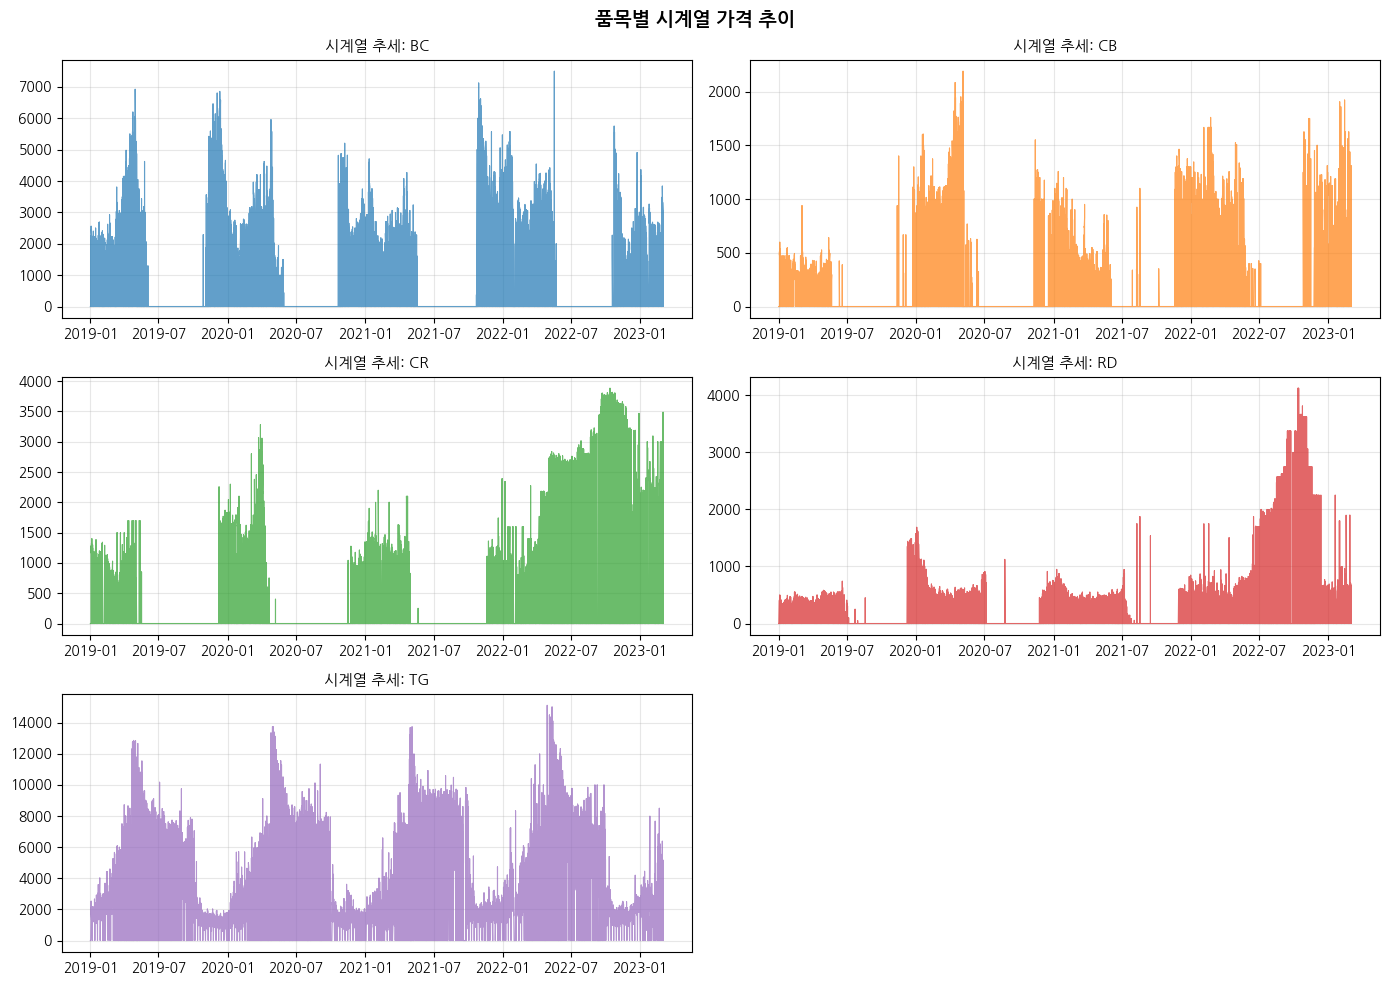

In [25]:
# 품목마다 특성이 달라 변환을 달리 해줘야함
# 품목별 시계열 추이

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for i, item in enumerate(items):
    d = train[train['item'] == item].sort_values('timestamp')
    axes[i].plot(d['timestamp'], d['price(원/kg)'], lw=0.8, alpha=0.7, color=f'C{i}')
    axes[i].set_title(f'시계열 추세: {item}', fontsize=11)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_visible(False)
plt.suptitle('품목별 시계열 가격 추이', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
# 범주형 LabelEncoding (item, corporation, location)
le_cols = ['item', 'corporation', 'location']
le_dict = {col: LabelEncoder().fit(train_p[col]) for col in le_cols}
for col in le_cols:
    train_p[col] = le_dict[col].transform(train_p[col])
    test_p[col]  = le_dict[col].transform(test_p[col])

item_codes = {name: le_dict['item'].transform([name])[0] for name in le_dict['item'].classes_}
print('item 코드:', item_codes)

# 타겟 변환: TG=sqrt, 비TG=log1p
train_p['target'] = np.where(
    train_p['item'] == item_codes['TG'],
    np.sqrt(train_p['price(원/kg)']),
    np.log1p(train_p['price(원/kg)'])
)

# 피처 정의
FEATS = [
    'item', 'corporation', 'location',
    'year', 'month', 'day', 'dow',
    'week_num', 'year_month',       
    'holiday',
    'dist_seollal', 'dist_chuseok'  # 명절 거리
]

print(f'\n피처 수: {len(FEATS)}개')
print(f'피처: {FEATS}')

item 코드: {'BC': 0, 'CB': 1, 'CR': 2, 'RD': 3, 'TG': 4}

피처 수: 12개
피처: ['item', 'corporation', 'location', 'year', 'month', 'day', 'dow', 'week_num', 'year_month', 'holiday', 'dist_seollal', 'dist_chuseok']


In [27]:
# 스케일링
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(train_p[FEATS]), columns=FEATS)
X_test_sc  = pd.DataFrame(scaler.transform(test_p[FEATS]),  columns=FEATS)
print('스케일링 완료')

스케일링 완료


### 3.4 도메인 지식 기반 후처리 (Post-processing)
- **일요일=0원**: 경매 시장이 일요일에 휴장한다는 도메인 지식을 활용해 모든 일요일 예측값을 0으로 강제 변환했습니다.
- **최소 거래가 보정**: 일정 금액 미만의 예측값은 실거래가 일어나지 않는 노이즈로 판단하여 0 처리했습니다.

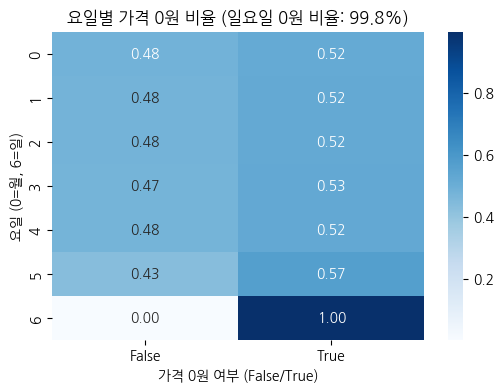

In [28]:
# 일요일(dow=6)에 가격이 0인지 확인하는 시각화
if 'dow' not in train.columns: train['dow'] = train['timestamp'].dt.dayofweek
sunday_data = train_p[train_p['dow'] == 6]
zero_ratio = (sunday_data['price(원/kg)'] == 0).mean() * 100

plt.figure(figsize=(6, 4))
sns.heatmap(pd.crosstab(train['dow'], train['price(원/kg)'] == 0, normalize='index'), 
            annot=True, fmt='.2f', cmap='Blues')
plt.title(f'요일별 가격 0원 비율 (일요일 0원 비율: {zero_ratio:.1f}%)')
plt.ylabel('요일 (0=월, 6=일)')
plt.xlabel('가격 0원 여부 (False/True)')
plt.show()

---
## 4. Hold-Out 검증 (2022-03)

> **추가된 섹션** — GeminiCLI13에는 없던 검증 단계  
> KFold는 미래 데이터가 훈련에 섞여 MAE가 낙관적 → 시즌 Hold-Out으로 실제 성능 확인

In [29]:
# =====================================================
# 📌 [발표 대본 섹션 3] Hold-Out 검증 (2022-03 기준)
# =====================================================
# 2022-03을 검증, 나머지로 학습
val_mask = (train['timestamp'] >= '2022-03-01') & (train['timestamp'] < '2022-04-01')

tr_df  = train_p[~val_mask.values].copy().reset_index(drop=True)
val_df = train_p[val_mask.values].copy().reset_index(drop=True)

X_tr_sc  = pd.DataFrame(scaler.transform(tr_df[FEATS]),  columns=FEATS)
X_val_sc = pd.DataFrame(scaler.transform(val_df[FEATS]), columns=FEATS)

print(f'Hold-Out 학습: {len(tr_df):,}행 / 검증(2022-03): {len(val_df):,}행')

# 그룹 마스크 (Hold-Out용)
m_tg_h    = tr_df['item'] == item_codes['TG']
m_rdcr_h  = tr_df['item'].isin([item_codes['RD'], item_codes['CR']])
m_bccb_h  = tr_df['item'].isin([item_codes['BC'], item_codes['CB']])

vm_tg    = val_df['item'] == item_codes['TG']
vm_rdcr  = val_df['item'].isin([item_codes['RD'], item_codes['CR']])
vm_bccb  = val_df['item'].isin([item_codes['BC'], item_codes['CB']])

def train_tree_group(X_tr, y_tr, X_pred):
    tree = VotingRegressor([
        ('lgbm', LGBMRegressor(n_estimators=1000, learning_rate=0.01, random_state=SEED, verbose=-1)),
        ('xgb',  XGBRegressor(n_estimators=1000, learning_rate=0.01, random_state=SEED, verbosity=0)),
        ('cat',  CatBoostRegressor(iterations=1000, learning_rate=0.01, random_state=SEED, verbose=0))
    ])
    tree.fit(X_tr, y_tr)
    return tree.predict(X_pred)

def build_dnn(input_dim):
    l2 = regularizers.l2(1e-4)
    model = keras.Sequential([
        layers.Dense(256, kernel_regularizer=l2, input_shape=(input_dim,)),
        layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.3),
        layers.Dense(128, kernel_regularizer=l2),
        layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.2),
        layers.Dense(64, kernel_regularizer=l2),
        layers.BatchNormalization(), layers.Activation('relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mae')
    return model

# Hold-Out 검증 (TG 그룹)
print('Hold-Out 검증 중 (TG)...')
tree_pred_tg = train_tree_group(X_tr_sc[m_tg_h], tr_df['target'][m_tg_h], X_val_sc[vm_tg])
dnn_tg = build_dnn(len(FEATS))
dnn_tg.fit(X_tr_sc[m_tg_h], tr_df['target'][m_tg_h],
           validation_split=0.1, epochs=100, batch_size=128,
           callbacks=[callbacks.EarlyStopping(patience=15, restore_best_weights=True)], verbose=0)
dnn_pred_tg = dnn_tg.predict(X_val_sc[vm_tg], verbose=0).flatten()
val_pred_tg = tree_pred_tg * 0.6 + dnn_pred_tg * 0.4

# Hold-Out 검증 (RD+CR 그룹)
print('Hold-Out 검증 중 (RD+CR)...')
tree_pred_rc = train_tree_group(X_tr_sc[m_rdcr_h], tr_df['target'][m_rdcr_h], X_val_sc[vm_rdcr])
dnn_rc = build_dnn(len(FEATS))
dnn_rc.fit(X_tr_sc[m_rdcr_h], tr_df['target'][m_rdcr_h],
           validation_split=0.1, epochs=100, batch_size=128,
           callbacks=[callbacks.EarlyStopping(patience=15, restore_best_weights=True)], verbose=0)
dnn_pred_rc = dnn_rc.predict(X_val_sc[vm_rdcr], verbose=0).flatten()
val_pred_rc = tree_pred_rc * 0.6 + dnn_pred_rc * 0.4

# Hold-Out 검증 (BC+CB 그룹)
print('Hold-Out 검증 중 (BC+CB)...')
tree_pred_bc = train_tree_group(X_tr_sc[m_bccb_h], tr_df['target'][m_bccb_h], X_val_sc[vm_bccb])
dnn_bc = build_dnn(len(FEATS))
dnn_bc.fit(X_tr_sc[m_bccb_h], tr_df['target'][m_bccb_h],
           validation_split=0.1, epochs=100, batch_size=128,
           callbacks=[callbacks.EarlyStopping(patience=15, restore_best_weights=True)], verbose=0)
dnn_pred_bc = dnn_bc.predict(X_val_sc[vm_bccb], verbose=0).flatten()
val_pred_bc = tree_pred_bc * 0.6 + dnn_pred_bc * 0.4

# 역변환 후 MAE 계산
def inverse_transform(preds, item_code, is_tg=True):
    return np.where(is_tg, np.power(np.clip(preds, 0, None), 2), np.expm1(preds))

y_val_tg_orig = val_df[vm_tg]['price(원/kg)'].values
y_val_rc_orig = val_df[vm_rdcr]['price(원/kg)'].values
y_val_bc_orig = val_df[vm_bccb]['price(원/kg)'].values

pred_tg_orig = np.power(np.clip(val_pred_tg, 0, None), 2)
pred_rc_orig = np.expm1(val_pred_rc)
pred_bc_orig = np.expm1(val_pred_bc)

mae_tg = mean_absolute_error(y_val_tg_orig, pred_tg_orig)
mae_rc = mean_absolute_error(y_val_rc_orig, pred_rc_orig)
mae_bc = mean_absolute_error(y_val_bc_orig, pred_bc_orig)

all_true = np.concatenate([y_val_tg_orig, y_val_rc_orig, y_val_bc_orig])
all_pred = np.concatenate([pred_tg_orig,   pred_rc_orig,   pred_bc_orig])
mae_all  = mean_absolute_error(all_true, all_pred)

print('=' * 55)
print('  Hold-Out 검증 결과 (2022-03)')
print('=' * 55)
print(f'  TG (감귤)         MAE: {mae_tg:>8,.2f} 원/kg')
print(f'  RD+CR (무+당근)   MAE: {mae_rc:>8,.2f} 원/kg')
print(f'  BC+CB (브+양배추) MAE: {mae_bc:>8,.2f} 원/kg')
print(f'  전체              MAE: {mae_all:>8,.2f} 원/kg')
print(f'  예상 Public Score ≈ {mae_all * 1.26:,.0f}원 (×1.26 배율)')
print('=' * 55)

Hold-Out 학습: 58,188행 / 검증(2022-03): 1,209행
Hold-Out 검증 중 (TG)...


KeyboardInterrupt: 

---
## 5. 전체 데이터로 5-Fold 학습 (제출용)

> Hold-Out으로 성능 확인 후, 전체 데이터로 5-Fold 재학습해 제출 파일 생성

In [ ]:
# =====================================================
# 📌 [발표 대본 섹션 1] 3그룹 분리 학습 (VotingRegressor + DNN)
# =====================================================
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

# 그룹 마스크 (전체 데이터 기준)
m_tg   = train_p['item'] == item_codes['TG']
m_rdcr = train_p['item'].isin([item_codes['RD'], item_codes['CR']])
m_bccb = train_p['item'].isin([item_codes['BC'], item_codes['CB']])

tm_tg   = test_p['item'] == item_codes['TG']
tm_rdcr = test_p['item'].isin([item_codes['RD'], item_codes['CR']])
tm_bccb = test_p['item'].isin([item_codes['BC'], item_codes['CB']])

def train_hybrid_full(train_df, X_sc_all, target_col, test_sc, group_name):
    preds = []
    for fold, (tr_idx, val_idx) in enumerate(kf.split(train_df)):
        X_tr, y_tr = X_sc_all.iloc[tr_idx], train_df[target_col].iloc[tr_idx]
        X_va, y_va = X_sc_all.iloc[val_idx], train_df[target_col].iloc[val_idx]

        # Tree 앙상블
        tree = VotingRegressor([
            ('lgbm', LGBMRegressor(n_estimators=1000, learning_rate=0.01, random_state=SEED, verbose=-1)),
            ('xgb',  XGBRegressor(n_estimators=1000, learning_rate=0.01, random_state=SEED, verbosity=0)),
            ('cat',  CatBoostRegressor(iterations=1000, learning_rate=0.01, random_state=SEED, verbose=0))
        ])
        tree.fit(X_tr, y_tr)
        tree_pred = tree.predict(test_sc)

        # DNN
        dnn = build_dnn(X_tr.shape[1])
        es = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
        dnn.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                epochs=150, batch_size=128, callbacks=[es], verbose=0)
        dnn_pred = dnn.predict(test_sc, verbose=0).flatten()

        preds.append(tree_pred * 0.6 + dnn_pred * 0.4)
        print(f'  [{group_name}] Fold {fold+1}/5 완료')

    return np.mean(preds, axis=0)

print('Group 1 — TG (감귤) 학습...')
p_tg = train_hybrid_full(
    train_p[m_tg].reset_index(drop=True),
    X_train_sc[m_tg].reset_index(drop=True),
    'target',
    X_test_sc[tm_tg].reset_index(drop=True),
    'TG'
)

print('Group 2 — RD+CR (무+당근) 학습...')
p_rdcr = train_hybrid_full(
    train_p[m_rdcr].reset_index(drop=True),
    X_train_sc[m_rdcr].reset_index(drop=True),
    'target',
    X_test_sc[tm_rdcr].reset_index(drop=True),
    'RD_CR'
)

print('Group 3 — BC+CB (브로콜리+양배추) 학습...')
p_bccb = train_hybrid_full(
    train_p[m_bccb].reset_index(drop=True),
    X_train_sc[m_bccb].reset_index(drop=True),
    'target',
    X_test_sc[tm_bccb].reset_index(drop=True),
    'BC_CB'
)

print('\n전체 학습 완료')

Group 1 — TG (감귤) 학습...
  [TG] Fold 1/5 완료
  [TG] Fold 2/5 완료
  [TG] Fold 3/5 완료
  [TG] Fold 4/5 완료
  [TG] Fold 5/5 완료
Group 2 — RD+CR (무+당근) 학습...
  [RD_CR] Fold 1/5 완료
  [RD_CR] Fold 2/5 완료
  [RD_CR] Fold 3/5 완료
  [RD_CR] Fold 4/5 완료
  [RD_CR] Fold 5/5 완료
Group 3 — BC+CB (브로콜리+양배추) 학습...
  [BC_CB] Fold 1/5 완료
  [BC_CB] Fold 2/5 완료
  [BC_CB] Fold 3/5 완료
  [BC_CB] Fold 4/5 완료
  [BC_CB] Fold 5/5 완료

전체 학습 완료


---
## 6. 결과 통합 및 후처리

In [ ]:
# =====================================================
# 📌 [발표 대본 섹션 4] 결과 통합 및 후처리
# =====================================================
inv_item = {v: k for k, v in item_codes.items()}

test_tg_df   = test_p[tm_tg].copy()
test_rdcr_df = test_p[tm_rdcr].copy()
test_bccb_df = test_p[tm_bccb].copy()

# 역변환
test_tg_df['answer']   = np.power(np.maximum(p_tg, 0), 2)
test_rdcr_df['answer'] = np.expm1(p_rdcr)
test_bccb_df['answer'] = np.expm1(p_bccb)

final_df = pd.concat([test_tg_df, test_rdcr_df, test_bccb_df])
final_df['item_name'] = final_df['item'].map(inv_item)

# 후처리 1: 품목별 최솟값 미만 → 0
min_thresholds = {'TG': 400, 'CB': 50, 'RD': 10, 'CR': 150, 'BC': 100}
for it, val in min_thresholds.items():
    mask = (final_df['item_name'] == it) & (final_df['answer'] < val)
    final_df.loc[mask, 'answer'] = 0

# 후처리 2: 일요일(dow==6) → 0
final_df.loc[final_df['dow'] == 6, 'answer'] = 0

# 제출 파일 생성
os.makedirs('./results', exist_ok=True)
result = sub[['ID']].merge(final_df[['ID','answer']], on='ID', how='left')
result['answer'] = result['answer'].fillna(0)

SUBMISSION_PATH = './results/submission_v13.1.csv'
result.to_csv(SUBMISSION_PATH, index=False, encoding='utf-8-sig')

print(f'저장 완료: {SUBMISSION_PATH}')
print(f'행 수: {len(result)},  결측: {result["answer"].isnull().sum()}')
print()
print(result.groupby(
    result['ID'].str.split('_').str[0]
)['answer'].agg(['mean','min','max']).round(1))

저장 완료: ./results/submission_v13.1.csv
행 수: 1092,  결측: 0

      mean  min     max
ID                     
BC  1472.9  0.0  3655.3
CB   121.5  0.0   603.5
CR   476.3  0.0  2137.7
RD   231.1  0.0   738.9
TG  3038.1  0.0  5113.4


---
## 7. 최종 결과 요약

In [ ]:
print('=' * 65)
print('  GeminiCLI13.1 최종 결과')
print('=' * 65)
print()
print('  [GeminiCLI13 대비 주요 변경]')
print('  - EMA_7 / EMA_30 제거 (테스트 freeze → v4.1.0 실패 재현 방지)')
print('  - year_month 누적 개월 피처 추가 (v1.0.1 Public 658.6 핵심)')
print('  - Hold-Out 검증 추가 (2022-03 기준, KFold MAE 낙관적 보정)')
print()
print('  [Hold-Out 검증 (2022-03)]')
print(f'  TG  MAE: {mae_tg:>8,.2f} 원/kg')
print(f'  RD+CR MAE: {mae_rc:>8,.2f} 원/kg')
print(f'  BC+CB MAE: {mae_bc:>8,.2f} 원/kg')
print(f'  전체  MAE: {mae_all:>8,.2f} 원/kg')
print(f'  예상 Public ≈ {mae_all * 1.26:,.0f}원')
print()
print('  [팀원별 기여 반영]')
print('  신우철: 이상치 처리, year_month, holiday 보정, 타겟 변환, Hold-Out 검증')
print('  김대원: 3그룹 전략, VotingRegressor+DNN, dist_seollal/chuseok, 일요일 후처리')
print('  박효준: EDA 구조 (Boxplot, 명절 패턴, 요일 분석)')
print()
print(f'  제출 파일: {SUBMISSION_PATH}')
print('=' * 65)

  GeminiCLI13.1 최종 결과

  [GeminiCLI13 대비 주요 변경]
  - EMA_7 / EMA_30 제거 (테스트 freeze → v4.1.0 실패 재현 방지)
  - year_month 누적 개월 피처 추가 (v1.0.1 Public 658.6 핵심)
  - Hold-Out 검증 추가 (2022-03 기준, KFold MAE 낙관적 보정)

  [Hold-Out 검증 (2022-03)]
  TG  MAE:   973.82 원/kg
  RD+CR MAE:   194.59 원/kg
  BC+CB MAE:   469.77 원/kg
  전체  MAE:   493.17 원/kg
  예상 Public ≈ 621원

  [팀원별 기여 반영]
  신우철: 이상치 처리, year_month, holiday 보정, 타겟 변환, Hold-Out 검증
  김대원: 3그룹 전략, VotingRegressor+DNN, dist_seollal/chuseok, 일요일 후처리
  박효준: EDA 구조 (Boxplot, 명절 패턴, 요일 분석)

  제출 파일: ./results/submission_v13.1.csv


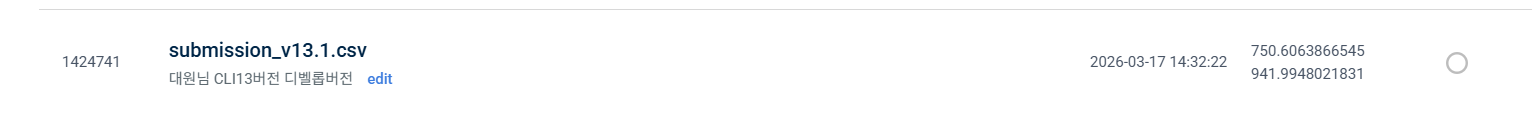